# Walker entanglement vs gMPS bond dimension, on small systems

Two notebooks look at Hubbard CPMC walkers from different sides:

- **`sd_to_mps.ipynb`** measures their **entanglement**: the entropy $S$ at every cut, from the eigenvalues $\nu$ of the correlation matrix on one side of the cut. It uses $L=8$, $U=6$ and a free-electron trial, and reports $e^{S}$ as an "effective dimension".
- **`fixed_block_walkers.ipynb`** measures what **converting them to a Gaussian MPS** costs: Fishman–White block sizes, the norm lost by the fixed-block plan, and the error of production's bond truncation (`plan_bonds` + `channel_mps`). It uses $L=32$, $U=4$ and a UHF trial.

The expectation connecting them is that low entanglement means a small bond. This notebook checks that the two agree by putting everything on the same walkers, and it adds the common ground truth that neither notebook has: **the walkers' Schmidt values**.

**References, as in production.** `mps_cpmc_new.py` builds the gMPS gate circuit and the per-sector kept counts on one reference determinant: the trial's natural orbitals (`plan_reference="natural"`). It also starts the walkers there. Two trials are used:

| trial | plan reference and walker start | walkers guided by |
|---|---|---|
| UHF, self-consistent Néel | the UHF determinant, which is its own natural-orbital determinant | the UHF determinant |
| DMRG at bond $\chi_T$ = `TRIAL_CHI`, production's `run_dmrg` | the $N$ most occupied natural orbitals of each spin | the DMRG state, exactly |

The walker sets are $L=8$ and $12$, $U=4$ and $6$, with both trials. sd_to_mps's own walkers (free-electron trial) enter only T0, as a check of conventions.

**Why small systems first.** For $L\le 14$, a walker spin channel fits in memory as a dense many-body vector: $\langle n|\phi\rangle=\det Q[\text{occupied rows of } n]$, a vector of $2^L$ entries. An SVD of that vector reshaped at cut $b$ gives the exact Schmidt values. Every other quantity then has an exact reference:

| quantity | from | compared with |
|---|---|---|
| Schmidt values $\lambda^{(b)}_i$ | **dense SVD** (ground truth) | $\prod_k(\nu_k\text{ or }1-\nu_k)$ from the correlation spectrum; the gMPS of the own plan and of the fixed plan |
| entropy $S_b=-\sum_i\lambda_i\ln\lambda_i$ | dense $\lambda$ | sd_to_mps's formula in $\nu$, and its saved values |
| fixed-plan fidelity | exact overlap of the gMPS with the dense state | fixed_block's $\det R[\mathrm{occ},:]^2$ |
| truncation error at bond $\chi$ | exact overlap with the dense state | the optimum $\max_b\varepsilon_b(\chi)$, $\varepsilon_b(\chi)=1-\sum_{i\le\chi}\lambda^{(b)}_i$, which no MPS can beat |
| bond dimension | gMPS bond per cut | Schmidt rank at a tolerance; $2^{m_b}$ with $m_b$ the modes not pure to $\varepsilon$ |

| symbol | meaning |
|---|---|
| $L$, $N$, $U$ | sites, electrons per spin (half filling), interaction; open chain, $t=1$ |
| $Q$ | orthonormalised $L\times N$ orbitals of one walker spin channel |
| $\nu^{(b)}_k$ | eigenvalues of $QQ^{\mathsf T}$ restricted to the smaller side of cut $b$ |
| $S_{\max}$, $D_{\rm eff}$ | per-spin entropy at the most entangled cut, and $e^{S_{\max}}$; sd_to_mps's $S$ is $S_\uparrow+S_\downarrow$ |
| $\chi$ | bond per spin channel (production's `walker_channel_chi`); the full walker is an MPS with bond $\chi_\uparrow\chi_\downarrow$ |
| $B_k$ | block size at site $k$: own plan $B_k(\phi)$, fixed plan $B_k^{\rm ref}$ from the plan reference |

**Tests.**

- **S: Schmidt values, four ways.** Dense SVD, $\nu$ products, own-plan gMPS, and fixed-plan gMPS.
- **T0: conventions.**
- **T1: entanglement along the run.**
- **T2: optimal vs achieved truncation, with exact fidelities.**
- **T3: is $e^{S}$ the bond you need?**
- **T4: bonds, ranks and active modes.**

Larger systems come later with the same tests. There the dense state is replaced by the $\nu$ products, which S validates here.

In [53]:
# ---- walker sets (Hubbard, open chain, t = 1, half filling), all small enough for dense states
SETS = {f"L{L}_U{U}_{trial}": dict(L=L, U=float(U), trial=trial)
        for L in (8, 12) for U in (4, 8) for trial in ("uhf", "dmrg")}
TRIAL_CHI, DMRG_SWEEPS = 8, 14    # DMRG trial: production's run_dmrg at this bond (the L=32 sweeps used 8)
# ---- CPMC: trot's slow CPMC step (overlaps only), kept small for fast iteration
N_WALKERS, N_EQL, N_BLOCKS, N_PROP, DT, SEED = 50, 10, 30, 20, 0.01, 1234
# ---- analysis
EPS = 1.0e-10                  # purity tolerance of the adaptive plans (mps_cpmc_new default)
CHIS = (2, 4, 8, 16)           # bond per spin channel
DELTAS = (1e-2, 1e-4, 1e-6, 1e-9)
RANK_TOL = 1e-12               # Schmidt values above this count towards the rank (T4)
ANALYSE_SNAPSHOTS = 12         # evenly spaced snapshots per set in the dense analysis; None = all
# ---- every stage is cached in entanglement_vs_gmps_data/; recomputed if missing or RERUN
RERUN = False

In [54]:
import heapq
import json
from typing import NamedTuple
import sys
import time
from functools import lru_cache
from itertools import combinations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_new.py
import mps_cpmc_new as mcn
from mps_cpmc_new import (make_orbital_plan, channel_angles, channel_mps, plan_bonds, hopping_matrix,
                          gate_pair, sector_plan, _move_centre, _factor_block, _assemble)
from pyscf import fci
from trot.core.ops import MeasOps, TrialOps, k_energy
from trot.core.system import System
from trot.driver import make_run_blocks
from trot.ham.chol import HamChol
from trot.ham.hubbard import HamHubbard
from trot.meas.uhf import make_uhf_meas_ops
from trot.prop import blocks, cpmc_slow
from trot.prop.types import QmcParams
from trot.stat_utils import blocking_analysis_ratio
from trot.trial.uhf import UhfTrial, make_uhf_trial_ops

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a", "#3b9ab2", "#7a5230"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))
COLOR = {name: PALETTE[i % len(PALETTE)] for i, name in enumerate(SETS)}
LABEL = {name: f"L={s['L']}, U={s['U']:g}, {s['trial'].upper()} trial" for name, s in SETS.items()}
REF_NAME = {"uhf": "UHF determinant", "dmrg": "natural-orbital determinant"}

REPO = Path.cwd().parents[1]
SD_DIR = REPO / "runs" / "sd_to_mps_data" / "hubbard_l8_open_u6_free_cpmc_seed731009"
DATA_DIR = Path("entanglement_vs_gmps_data")
DATA_DIR.mkdir(exist_ok=True)


def save(fig, name):
    path = DATA_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")


def cached(path, compute):
    # np.load of the file at path, computing and saving it first if missing or RERUN
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **compute())
        print(f"computed {path.name} in {time.perf_counter() - start:.0f} s")
    return dict(np.load(path))

## Tools

- **Dense state and exact Schmidt values.** `dense_state` builds $\langle n|\phi\rangle=\det Q[\text{occ}(n)]$, with site 0 as the most significant bit, which is the gMPS site order. `dense_schmidt` SVDs it at every cut.
- **Correlation spectra** follow sd_to_mps: QR-orthonormalise, then take the eigenvalues of $QQ^{\mathsf T}$ on the smaller side of the cut. The larger side only adds modes that are 0 or 1 to roundoff.
- **`top_schmidt`** gives the $\chi$ largest $\prod_k(\nu_k\text{ or }1-\nu_k)$ by a best-first search over flipped modes. It doesn't enumerate all $2^{\#\rm modes}$ products.
- **gMPS.**
  - `channel_mps_np` is a NumPy port of `mps_cpmc_new.channel_mps` without truncation: same gates, centre moves and charge-blocked QR splits, using the module's own helpers with `xp=np`. It gives the same states as `channel_mps` to $10^{-15}$, up to an MPS gauge, and handles each walker's own plan, which is a different circuit for every walker.
  - Production's truncated conversion is the real thing: `channel_mps(Q, plan, plan_bonds(...))`, jitted and vmapped.
- **Optimal truncation.** `exact_mps` turns the dense state into an MPS by successive SVDs. `svd_compress` then truncates it right to left in canonical form, so every cut drops the smallest Schmidt values of the current state.

In [55]:
def orthonormal(W):
    return np.linalg.qr(W)[0]


@lru_cache(maxsize=None)
def _basis(L, N):
    combos = np.array(list(combinations(range(L), N)))
    return combos, (1 << (L - 1 - combos)).sum(axis=1)


def dense_state(Q):
    L, N = Q.shape
    combos, index = _basis(L, N)
    psi = np.zeros(2 ** L)
    psi[index] = np.linalg.det(Q[combos])
    return psi


def dense_schmidt(psi, L):
    # exact Schmidt values (descending) at every cut b = 1..L-1
    return [np.linalg.svd(psi.reshape(2 ** b, -1), compute_uv=False) ** 2 / np.dot(psi, psi) for b in range(1, L)]


def mps_to_dense(tensors):
    v = np.asarray(tensors[0])[0]
    for t in tensors[1:]:
        v = np.tensordot(v, np.asarray(t), axes=([-1], [0])).reshape(-1, np.asarray(t).shape[-1])
    return v.reshape(-1)


def dense_fidelity(psi, vec):
    return float(np.dot(psi, vec) ** 2 / (np.dot(psi, psi) * np.dot(vec, vec)))


def exact_mps(psi, L, cutoff=1e-15):
    tensors, M, Dl = [], psi.reshape(1, -1), 1
    for k in range(L - 1):
        u, s, vt = np.linalg.svd(M.reshape(Dl * 2, -1), full_matrices=False)
        keep = max(1, int(np.sum(s > cutoff * s[0])))
        tensors.append(u[:, :keep].reshape(Dl, 2, keep))
        M, Dl = s[:keep, None] * vt[:keep], keep
    tensors.append(M.reshape(Dl, 2, 1))
    return tensors


def svd_compress(tensors, chi):
    # left-canonicalise, then truncate right to left: optimal sequential truncation to bond chi
    A = [np.asarray(t, float) for t in tensors]
    for k in range(len(A) - 1):
        Dl, d, Dr = A[k].shape
        q, r = np.linalg.qr(A[k].reshape(Dl * d, Dr))
        A[k] = q.reshape(Dl, d, -1)
        A[k + 1] = np.einsum("ab,bpc->apc", r, A[k + 1])
    for k in range(len(A) - 1, 0, -1):
        Dl, d, Dr = A[k].shape
        u, s, vt = np.linalg.svd(A[k].reshape(Dl, d * Dr), full_matrices=False)
        keep = min(chi, len(s))
        A[k] = vt[:keep].reshape(keep, d, Dr)
        A[k - 1] = np.einsum("apb,bc->apc", A[k - 1], u[:, :keep] * s[:keep])
    return A


def cut_spectra(Q):
    L = Q.shape[0]
    side = lambda b: Q[:b] if b <= L - b else Q[b:]
    return [np.clip(np.linalg.eigvalsh(side(b) @ side(b).T), 0.0, 1.0) for b in range(1, L)]


def binary_entropy(nu, tol=1e-14):
    x = nu[(nu > tol) & (nu < 1 - tol)]
    return float(-np.sum(x * np.log(x) + (1 - x) * np.log1p(-x)))


def schmidt_entropy(lam):
    lam = lam[lam > 1e-300]
    return float(-np.sum(lam * np.log(lam)))


def top_schmidt(nu, chi):
    p = np.maximum(nu, 1 - nu)
    w = np.sort(np.minimum(nu, 1 - nu) / p)[::-1]
    w = w[w > 0]
    P0 = float(np.prod(p))
    out, heap = [P0], []
    if len(w):
        heapq.heappush(heap, (-P0 * w[0], 0, P0 * w[0]))
    while heap and len(out) < chi:
        _, j, val = heapq.heappop(heap)
        out.append(val)
        if j + 1 < len(w):
            heapq.heappush(heap, (-val * w[j + 1], j + 1, val * w[j + 1]))      # also flip mode j+1
            swap = val / w[j] * w[j + 1]
            heapq.heappush(heap, (-swap, j + 1, swap))                         # flip j+1 instead of j
    return np.array(out)


def discarded(lam, chis):
    cum = np.cumsum(lam)
    return np.array([max(1.0 - cum[min(c, len(cum)) - 1], 0.0) for c in chis])


def chi_needed(lam, deltas):
    tail = 1.0 - np.cumsum(lam)
    return np.array([int(np.argmax(tail <= d)) + 1 if (tail <= d).any() else len(tail) for d in deltas])


def channel_mps_np(Q, plan):
    # NumPy port of mps_cpmc_new.channel_mps, untruncated: returns (tensors, gauge), phi ~ gauge * MPS
    tensors = [np.eye(2)[int(o)].reshape(1, 2, 1) for o in plan.occupation]
    charges = [np.zeros(1, int)]
    for o in plan.occupation:
        charges.append(charges[-1] + int(o))
    angles, rows = channel_angles(Q, plan, xp=np)
    centre = None
    for site, theta in reversed(angles):
        centre = _move_centre(tensors, charges, centre, site, xp=np)
        pair = gate_pair(tensors[site], tensors[site + 1], theta, xp=np)
        Dl, _, _, Dr = pair.shape
        M = pair.reshape(2 * Dl, 2 * Dr)
        sp = sector_plan(charges[site], charges[site + 2])
        left, right = [], []
        for r, c, rank in sp.sectors:
            q, rr = _factor_block(M[np.ix_(r, c)], rank, False, np)
            left.append(q)
            right.append(rr)
        A, B = _assemble(left, right, sp, xp=np)
        tensors[site], tensors[site + 1] = A.reshape(Dl, 2, -1), B.reshape(-1, 2, Dr)
        charges[site + 1] = sp.middle_charges
        centre = site + 1
    gauge = np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)]))
    return tensors, gauge


def plan_fidelity(Q, plan):
    # fixed_block_walkers.ipynb's F = det(R[occ, :])^2
    _, rows = channel_angles(Q, plan, xp=np)
    return np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)])) ** 2

## Walker sets

All sets are run here with trot's CPMC: `cpmc_slow` (whose step needs only the trial overlap), `blocks.block` and `make_run_blocks`. A snapshot is saved after every block.

- **UHF trial.** trot's `UhfTrial` with `make_uhf_trial_ops`, and `make_uhf_meas_ops` on the on-site Cholesky Hamiltonian (fixed_block_walkers' pipeline).
- **DMRG trial.** Production's own trial: `mps_cpmc_new.run_dmrg` at bond `TRIAL_CHI`, then `densify_with_charges`, and $H|\Psi_T\rangle$ from `hubbard_mpo` and `apply_mpo`. At these sizes the whole trial fits in the determinant basis:
  $$M_T[I,J]=\langle I_\uparrow J_\downarrow|\Psi_T\rangle,\qquad \langle\Psi_T|\phi\rangle=a_\uparrow^{\mathsf T}M_T\,a_\downarrow,\qquad a_\sigma[I]=\det W_\sigma[I,:],$$
  over up strings $I$ and down strings $J$; this is $924\times924$ at $L=12$. $M_H$ holds $H\Psi_T$ in the same basis. The d=4 MPS orders the modes site by site (up before down on each site), while $a_\uparrow[I]\,a_\downarrow[J]$ puts all up modes first. Reordering costs $\prod_i(-1)^{n_{\uparrow i}N_\downarrow(<i)}$, the sign `combine_channels` applies.
  - At $L=8$ the overlap is checked against production's own `make_walker_ops(...).overlap`, with exact walker conversion.
  - The overlaps are exact, so the walkers are those of a DMRG-guided CPMC without truncation error.
  - The walkers start at the trial's natural orbitals: trot takes the natural orbitals of `get_rdm1`, and production's `walker_start="natural"` does the same.
- **Exact ground-state energies** come from pyscf FCI, as in sd_to_mps, and serve only as a sanity check of the runs.

In [56]:
def uhf_scf(h1, u, na, nb, guess=0.3, mix=0.5, tol=1e-12, iters=5000):
    # fixed_block_walkers.ipynb's SCF, unchanged
    n = h1.shape[0]
    stag = (-1.0) ** np.arange(n)
    da, db = na / n + guess * stag, nb / n - guess * stag
    for it in range(iters):
        _, va = np.linalg.eigh(h1 + u * np.diag(db))
        _, vb = np.linalg.eigh(h1 + u * np.diag(da))
        Ca, Cb = va[:, :na], vb[:, :nb]
        new_a, new_b = np.einsum("ik,ik->i", Ca, Ca), np.einsum("ik,ik->i", Cb, Cb)
        change = max(abs(new_a - da).max(), abs(new_b - db).max())
        da, db = (1 - mix) * da + mix * new_a, (1 - mix) * db + mix * new_b
        if change < tol:
            break
    return Ca, Cb


def dense4(tensors):
    # amplitudes of a d=4 MPS over all 4^L local states (site 0 most significant), contracted from both
    # ends so the largest intermediate is 4^(L/2) x bond
    L, h = len(tensors), len(tensors) // 2
    left = np.asarray(tensors[0])[0]
    for t in tensors[1:h]:
        left = np.tensordot(left, np.asarray(t), axes=([-1], [0])).reshape(-1, np.asarray(t).shape[-1])
    right = np.asarray(tensors[-1])[:, :, 0]
    for t in reversed(tensors[h:-1]):
        right = np.tensordot(np.asarray(t), right, axes=([-1], [0])).reshape(np.asarray(t).shape[0], -1)
    return (left @ right).reshape(-1)


def sector_matrix(vec4, L, N):
    # <I_up J_dn|state> in dense_state's string order, all up modes before all down modes
    combos, _ = _basis(L, N)
    occ = np.zeros((len(combos), L), int)
    occ[np.arange(len(combos))[:, None], combos] = 1
    local = occ[:, None, :] + 2 * occ[None, :, :]                        # d=4 local index n_up + 2 n_dn
    dn_left = np.concatenate([np.zeros((len(combos), 1), int), np.cumsum(occ, axis=1)[:, :-1]], axis=1)
    sign = (-1.0) ** (occ[:, None, :] * dn_left[None, :, :]).sum(-1)     # site-by-site -> up-then-down order
    return vec4[local @ (4 ** np.arange(L - 1, -1, -1))] * sign


def dmrg_trial(L, U):
    # production's DMRG trial as exact sector matrices, cached; at L <= 8 also checked against production's overlap
    def build():
        N = L // 2
        cfg = mcn.Config(L=L, n_up=N, n_down=N, interaction=U, trial_chi=TRIAL_CHI, dmrg_sweeps=DMRG_SWEEPS)
        mps, e_dmrg = mcn.run_dmrg(mcn.build_dmrg_hamiltonian(cfg), cfg)
        trial_np, trial_charges = mcn.densify_with_charges(mps, L)
        H_np = mcn.compress_mps(mcn.apply_mpo(mcn.hubbard_mpo(L, 1.0, U), trial_np))
        M_T, M_H = sector_matrix(dense4(trial_np), L, N), sector_matrix(dense4(H_np), L, N)
        norm = float(np.sum(M_T ** 2))
        gamma = np.stack(mcn.one_rdm(trial_np))
        check = float("nan")
        if L <= 8:
            nos = [mcn.natural_orbitals(g, N)[0] for g in gamma]
            plans = [make_orbital_plan(C, "adaptive", EPS) for C in nos]
            ops = mcn.make_walker_ops(*nos, *plans, None, None, trial_np, trial_charges, None)
            rng = np.random.default_rng(0)
            check = 0.0
            for _ in range(5):
                wu, wd = (C + 0.4 * rng.standard_normal(C.shape) for C in nos)
                dense = np.linalg.det(wu[_basis(L, N)[0]]) @ M_T @ np.linalg.det(wd[_basis(L, N)[0]])
                check = max(check, abs(dense / float(ops.overlap((jnp.asarray(wu), jnp.asarray(wd)))) - 1))
        return dict(M_T=M_T / np.sqrt(norm), M_H=M_H / np.sqrt(norm), gamma=gamma, e_dmrg=e_dmrg,
                    e_var=np.sum(M_T * M_H) / norm, sector_norm=norm, check=check)
    return cached(DATA_DIR / f"dmrg_trial_L{L}_U{U:g}_chi{TRIAL_CHI}.npz", build)


class DmrgTrial(NamedTuple):
    M_T: jax.Array                  # <I_up J_dn|Psi_T>
    M_H: jax.Array                  # <I_up J_dn|H Psi_T>
    rdm1: jax.Array                 # (2, L, L): its spin-resolved one-body density matrix


def make_dmrg_ops(L, N):
    combos = jnp.asarray(_basis(L, N)[0])
    amps = lambda w: jnp.linalg.det(w[combos])                          # <I|phi_sigma> for every string I

    def overlap(walker, trial):
        return amps(walker[0]) @ trial.M_T @ amps(walker[1])

    def energy(walker, ham_data, meas_ctx, trial):
        a, b = amps(walker[0]), amps(walker[1])
        return (a @ trial.M_H @ b) / (a @ trial.M_T @ b)

    return (TrialOps(overlap=overlap, get_rdm1=lambda trial: trial.rdm1),
            MeasOps(overlap=overlap, kernels={k_energy: energy}))


def run_cpmc(L, U, trial):
    # trot's CPMC with the slow step (it needs only overlaps), for a UHF or the exact DMRG trial
    h1 = hopping_matrix(L, 1.0)
    ham = HamHubbard(h1=jnp.asarray(h1), u=U)
    system = System(norb=L, nelec=(L // 2, L // 2), walker_kind="unrestricted")
    if trial["kind"] == "uhf":
        onsite = np.zeros((L, L, L))
        onsite[np.arange(L), np.arange(L), np.arange(L)] = np.sqrt(U)
        ham_meas = HamChol(h0=jnp.zeros(()), h1=jnp.asarray(h1), chol=jnp.asarray(onsite))
        tdata = UhfTrial(mo_coeff_a=jnp.asarray(trial["C"][0]), mo_coeff_b=jnp.asarray(trial["C"][1]))
        trial_ops, meas_ops = make_uhf_trial_ops(system), make_uhf_meas_ops(system)
    else:
        ham_meas = ham
        tdata = DmrgTrial(jnp.asarray(trial["M_T"]), jnp.asarray(trial["M_H"]), jnp.asarray(trial["gamma"]))
        trial_ops, meas_ops = make_dmrg_ops(L, L // 2)
    prop_ops = cpmc_slow.make_prop_ops(ham, "unrestricted")
    params = QmcParams(dt=DT, n_walkers=N_WALKERS, n_prop_steps=N_PROP, n_blocks=N_BLOCKS,
                       n_eql_blocks=N_EQL, seed=SEED)
    run_blocks = make_run_blocks(block_fn=blocks.block, sys=system, params=params,
                                 trial_ops=trial_ops, meas_ops=meas_ops, prop_ops=prop_ops)
    ctx = dict(ham_data=ham_meas, trial_data=tdata, meas_ctx=meas_ops.build_meas_ctx(ham_meas, tdata),
               prop_ctx=prop_ops.build_prop_ctx(ham, trial_ops.get_rdm1(tdata), params))
    state = prop_ops.init_prop_state(sys=system, ham_data=ham_meas, trial_ops=trial_ops,
                                     trial_data=tdata, meas_ops=meas_ops, params=params)
    ups, dns, energies, weights = [np.asarray(state.walkers[0])], [np.asarray(state.walkers[1])], [], []
    for b in range(N_EQL + N_BLOCKS):
        state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
        ups.append(np.asarray(state.walkers[0])); dns.append(np.asarray(state.walkers[1]))
        energies.append(float(scalars["energy"][0])); weights.append(float(scalars["weight"][0]))
    config = dict(L=L, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL, N_BLOCKS=N_BLOCKS, N_PROP=N_PROP, DT=DT, SEED=SEED)
    return dict(up=np.stack(ups), dn=np.stack(dns), energies=np.array(energies), weights=np.array(weights),
                config=json.dumps(config))


def exact_energy(L, U):
    def build():
        eri = np.zeros((L,) * 4)
        i = np.arange(L)
        eri[i, i, i, i] = U
        return dict(e=fci.direct_spin1.kernel(hopping_matrix(L, 1.0), eri, L, (L // 2, L // 2))[0])
    return float(cached(DATA_DIR / f"exact_L{L}_U{U:g}.npz", build)["e"])


WALK, TAU, SAMP, REF, TRIAL = {}, {}, {}, {}, {}
for name, s in SETS.items():
    L, N, U = s["L"], s["L"] // 2, s["U"]
    if s["trial"] == "uhf":
        TRIAL[name] = dict(kind="uhf", C=uhf_scf(hopping_matrix(L, 1.0), U, N, N))
        REF[name] = TRIAL[name]["C"]                     # a determinant's natural orbitals are its own orbitals
    else:
        TRIAL[name] = dict(kind="dmrg", **dmrg_trial(L, U))
        REF[name] = tuple(mcn.natural_orbitals(g, N)[0] for g in TRIAL[name]["gamma"])   # plan_reference="natural"
    path = DATA_DIR / f"{name}_nw{N_WALKERS}_b{N_EQL}+{N_BLOCKS}_s{SEED}_walkers.npz"
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **run_cpmc(L, U, TRIAL[name]))
        print(f"{name}: CPMC run in {time.perf_counter() - start:.0f} s, saved {path.name}")
    z = np.load(path)
    cfg = json.loads(str(z["config"]))
    WALK[name] = (z["up"], z["dn"])
    TAU[name] = np.arange(z["up"].shape[0]) * cfg["N_PROP"] * cfg["DT"]         # snapshot b after block b
    SAMP[name] = np.arange(z["up"].shape[0]) > cfg["N_EQL"]
    st = blocking_analysis_ratio(z["energies"][cfg["N_EQL"]:], z["weights"][cfg["N_EQL"]:], print_q=False)
    err = float("nan") if st["se_star"] is None else float(st["se_star"])
    t = TRIAL[name]
    trial_info = (f"DMRG trial <H> {float(t['e_var']):.5f} (sector weight {float(t['sector_norm']):.6f}"
                  + (f", overlap vs production {float(t['check']):.1e}" if np.isfinite(t["check"]) else "") + ")"
                  if t["kind"] == "dmrg" else "")
    print(f"{name:12s}: CPMC {float(st['mu']):.5f} +- {err:.5f}   exact {exact_energy(L, U):.5f}   {trial_info}")

L8_U4_uhf   : CPMC -4.04814 +- 0.03760   exact -4.23581   
L8_U4_dmrg  : CPMC -4.23549 +- 0.00103   exact -4.23581   DMRG trial <H> -4.21722 (sector weight 1.000000, overlap vs production 5.8e-15)
L8_U8_uhf: CPMC run in 3 s, saved L8_U8_uhf_nw50_b10+30_s1234_walkers.npz
computed exact_L8_U8.npz in 0 s
L8_U8_uhf   : CPMC -2.18263 +- 0.07668   exact -2.42083   
QC MPO site   0 / 8
QC MPO site   1 / 8
QC MPO site   2 / 8
QC MPO site   3 / 8
QC MPO site   4 / 8
QC MPO site   5 / 8
QC MPO site   6 / 8
QC MPO site   7 / 8
computed dmrg_trial_L8_U8_chi8.npz in 9 s
L8_U8_dmrg: CPMC run in 23 s, saved L8_U8_dmrg_nw50_b10+30_s1234_walkers.npz
L8_U8_dmrg  : CPMC -2.41743 +- 0.00052   exact -2.42083   DMRG trial <H> -2.41546 (sector weight 1.000000, overlap vs production 2.7e-15)
L12_U4_uhf  : CPMC -6.31380 +- 0.03423   exact -6.52315   
L12_U4_dmrg : CPMC -6.51314 +- 0.00117   exact -6.52315   DMRG trial <H> -6.48564 (sector weight 1.000000)
L12_U8_uhf: CPMC run in 3 s, saved L12_U8_uhf_nw50_b10+

## T0: conventions

- **Entropy.** On sd_to_mps's own saved walkers ($L=8$, $U=6$, free-electron trial), the two spins' $\nu$-entropies, summed, must reproduce its saved `entropy_by_cut`.
- **Spin symmetry.** At half filling on a bipartite chain, trot's spin-decomposition HS fields, together with a particle-hole symmetric trial and start, keep $P_\downarrow=1-SP_\uparrow S$ with $S=\mathrm{diag}((-1)^i)$. The ↓ channel is then the particle-hole image of the ↑ one, with the same Schmidt values, and the per-spin tests use ↑ only. It is checked on every set.

In [57]:
cfg = json.load(open(SD_DIR / "config.json"))
ids = np.arange(cfg["snapshot_every_blocks"], cfg["n_eql_blocks"] + cfg["n_blocks"] + 1, cfg["snapshot_every_blocks"])
snaps = [np.load(SD_DIR / "walkers" / f"block_state_{b:05d}.npz") for b in ids]
up, dn = np.stack([z["walkers_0"] for z in snaps]), np.stack([z["walkers_1"] for z in snaps])
ref = np.load(SD_DIR / "walker_entanglement.npz")["entropy_by_cut"]
ours = np.array([[[binary_entropy(a) + binary_entropy(b) for a, b in zip(cut_spectra(orthonormal(x)), cut_spectra(orthonormal(y)))]
                  for x, y in zip(su, sd)] for su, sd in zip(up, dn)])
print(f"sd_to_mps's L=8, U=6 walkers: our entropy vs its entropy_by_cut, max |diff| = {np.abs(ours - ref).max():.1e} "
      f"over {ref.size} values")

SPINS = {}
for name, (up, dn) in WALK.items():
    L = up.shape[2]
    stag = np.diag((-1.0) ** np.arange(L))
    worst = 0.0
    for s in range(up.shape[0]):
        for w in range(0, up.shape[1], 10):
            Pu, Pd = (x @ np.linalg.solve(x.T @ x, x.T) for x in (up[s, w], dn[s, w]))
            worst = max(worst, np.abs(Pd - (np.eye(L) - stag @ Pu @ stag)).max())
    SPINS[name] = (0,) if worst < 1e-10 else (0, 1)
    print(f"{name:14s}: max |P_dn - (1 - S P_up S)| = {worst:.1e}  ->  per-spin tests on spin(s) {SPINS[name]}")

sd_to_mps's L=8, U=6 walkers: our entropy vs its entropy_by_cut, max |diff| = 5.8e-14 over 77000 values
L8_U4_uhf     : max |P_dn - (1 - S P_up S)| = 1.4e-14  ->  per-spin tests on spin(s) (0,)
L8_U4_dmrg    : max |P_dn - (1 - S P_up S)| = 1.0e-10  ->  per-spin tests on spin(s) (0, 1)
L8_U8_uhf     : max |P_dn - (1 - S P_up S)| = 1.3e-14  ->  per-spin tests on spin(s) (0,)
L8_U8_dmrg    : max |P_dn - (1 - S P_up S)| = 1.3e-10  ->  per-spin tests on spin(s) (0, 1)
L12_U4_uhf    : max |P_dn - (1 - S P_up S)| = 1.6e-14  ->  per-spin tests on spin(s) (0,)
L12_U4_dmrg   : max |P_dn - (1 - S P_up S)| = 2.6e-11  ->  per-spin tests on spin(s) (0,)
L12_U8_uhf    : max |P_dn - (1 - S P_up S)| = 1.3e-14  ->  per-spin tests on spin(s) (0,)
L12_U8_dmrg   : max |P_dn - (1 - S P_up S)| = 1.9e-03  ->  per-spin tests on spin(s) (0, 1)


## The analysis: every snapshot, every walker

For each walker spin channel, the analysis computes:

- **S.** Exact Schmidt values from the dense state, and their difference from:
  - the $\nu$ products;
  - the own-plan gMPS;
  - the fixed-plan gMPS.

  The gMPS Schmidt values are taken from their own dense vectors, so no canonical form is assumed.
- **T0/T1.** Entropies from $\lambda$ and from $\nu$; the own-plan block sizes $B_k(\phi)$; and the fixed-plan fidelity, both exactly (overlap with the dense state) and by fixed_block's formula $\det R[\mathrm{occ},:]^2$.
- **T2.** For each $\chi$:
  - (a) the optimal worst cut, $\max_b\varepsilon_b(\chi)$;
  - (b) $\sum_b\varepsilon_b(\chi)$;
  - (c) `svd_compress` of the exact MPS;
  - (d) production: `channel_mps(Q, plan, plan_bonds(ref, plan, χ))`.

  (c) and (d) are **exact fidelities with the dense state**. $\delta O=|O_{\rm gMPS}/O-1|$ is the error of the whole walker's overlap with the trial when both spin channels are converted as in (d); for the DMRG trial this is $a_\uparrow^{\mathsf T}M_Ta_\downarrow$ with the gMPS amplitudes.
- **T3.** $\chi_{\rm needed}(\delta)$ from the exact $\lambda$, for one spin and for the full walker. The full walker's Schmidt values at a cut are the products $\lambda^\uparrow_i\lambda^\downarrow_j$.
- **T4.** Bonds per cut of both gMPS; the Schmidt rank above `RANK_TOL`; and $m_b$, the $\nu$ not pure to $\varepsilon$.

In [58]:
PLAN = {name: [make_orbital_plan(C, "adaptive", EPS) for C in REF[name]] for name in SETS}
for name, plans in PLAN.items():
    print(f"{name:14s} fixed plan B_k (↑): {plans[0].block_sizes.tolist()}   rank bound min(N, L-N)+1 = {SETS[name]['L'] // 2 + 1}")


def selected(name):
    n = len(TAU[name])
    if ANALYSE_SNAPSHOTS is None or ANALYSE_SNAPSHOTS >= n:
        return np.arange(n)
    return np.unique(np.linspace(0, n - 1, ANALYSE_SNAPSHOTS).round().astype(int))


def analyse(name):
    up, dn = WALK[name]
    sel = selected(name)
    up, dn = up[sel], dn[sel]
    n_snap, nw, L, N = up.shape
    spins, nc, nd = SPINS[name], len(CHIS), len(DELTAS)
    kind, idx = TRIAL[name]["kind"], _basis(L, N)[1]
    trial_dense = [dense_state(C) for C in TRIAL[name]["C"]] if kind == "uhf" else None
    M_T = TRIAL[name]["M_T"] if kind == "dmrg" else None
    prod = {(sigma, c): jax.jit(jax.vmap(lambda q, sigma=sigma, c=c: channel_mps(
                q, PLAN[name][sigma], plan_bonds(REF[name][sigma], PLAN[name][sigma], c, 0.0))[::2]))
            for sigma in (0, 1) for c in CHIS}
    shape = (n_snap, nw, len(spins))
    out = dict(
        S_nu=np.zeros((n_snap, nw, 2, L - 1)), S_dense=np.zeros(shape + (L - 1,)),
        dev_nu=np.zeros(shape), dev_own=np.zeros(shape), dev_fixed=np.zeros(shape),
        F_own=np.zeros(shape), F_fixed=np.zeros(shape), F_fixed_det=np.zeros(shape),
        B=np.zeros(shape + (L - 1,), np.int16), m=np.zeros(shape + (L - 1,), np.int16),
        rank=np.zeros(shape + (L - 1,), np.int32), bond_own=np.zeros(shape + (L - 1,), np.int32),
        a=np.zeros(shape + (nc,)), b=np.zeros(shape + (nc,)), c=np.zeros(shape + (nc,)), d=np.zeros(shape + (nc,)),
        dO=np.zeros((n_snap, nw, nc)), need=np.zeros(shape + (nd,), np.int32), need_walker=np.zeros((n_snap, nw, nd), np.int32),
        centre_lam=np.zeros(shape + (2 ** min(L // 2, 8),)), snapshots=sel)
    for s in range(n_snap):
        Qs = [np.stack([orthonormal(W) for W in (up, dn)[sigma][s]]) for sigma in (0, 1)]
        for sigma in (0, 1):
            out["S_nu"][s, :, sigma] = [[binary_entropy(nu) for nu in cut_spectra(Q)] for Q in Qs[sigma]]
        cut = {k: jax.tree_util.tree_map(np.asarray, f(jnp.asarray(Qs[k[0]]))) for k, f in prod.items()}
        for w in range(nw):
            lam_spin = []
            for i, sigma in enumerate(spins):
                Q = Qs[sigma][w]
                psi = dense_state(Q)
                lam = dense_schmidt(psi, L)
                lam_spin.append(lam)
                spec = cut_spectra(Q)
                dev = 0.0
                for nu, l in zip(spec, lam):
                    t = top_schmidt(nu, len(l))
                    dev = max(dev, np.abs(np.pad(t, (0, len(l) - len(t))) - l).max())
                out["dev_nu"][s, w, i] = dev
                out["S_dense"][s, w, i] = [schmidt_entropy(l) for l in lam]
                out["m"][s, w, i] = [int(np.sum(np.minimum(nu, 1 - nu) > EPS)) for nu in spec]
                out["rank"][s, w, i] = [int(np.sum(l > RANK_TOL)) for l in lam]
                cl = lam[L // 2 - 1][: out["centre_lam"].shape[-1]]
                out["centre_lam"][s, w, i, : len(cl)] = cl
                own = make_orbital_plan(Q, "adaptive", EPS)
                out["B"][s, w, i] = own.block_sizes
                for key, plan in (("own", own), ("fixed", PLAN[name][sigma])):
                    tensors, g = channel_mps_np(Q, plan)
                    v = mps_to_dense(tensors)
                    out[f"F_{key}"][s, w, i] = dense_fidelity(psi, v)
                    out[f"dev_{key}"][s, w, i] = max(np.abs(a - b).max() for a, b in zip(dense_schmidt(v, L), lam))
                    if key == "own":
                        out["bond_own"][s, w, i] = [t.shape[2] for t in tensors[:-1]]
                out["F_fixed_det"][s, w, i] = plan_fidelity(Q, PLAN[name][sigma])
                eps = np.array([discarded(l, CHIS) for l in lam])
                out["a"][s, w, i], out["b"][s, w, i] = eps.max(0), eps.sum(0)
                out["need"][s, w, i] = np.array([chi_needed(l, DELTAS) for l in lam]).max(0)
                exact = exact_mps(psi, L)
                for k, c in enumerate(CHIS):
                    out["c"][s, w, i, k] = 1 - dense_fidelity(psi, mps_to_dense(svd_compress(exact, c)))
                    tensors, gauges = cut[(sigma, c)]
                    v = mps_to_dense([t[w] for t in tensors])
                    out["d"][s, w, i, k] = 1 - dense_fidelity(psi, v)
            # trial-overlap error of production's conversion, for the whole walker (both spins): a DMRG trial
            # does not factorise over spins, so O = a_up^T M_T a_dn with the gMPS amplitudes in place of a
            psis = [dense_state(Qs[sigma][w]) for sigma in (0, 1)]
            for k, c in enumerate(CHIS):
                vs = [mps_to_dense([t[w] for t in cut[(sigma, c)][0]]) for sigma in (0, 1)]
                gs = [cut[(sigma, c)][1][w] for sigma in (0, 1)]
                if kind == "uhf":
                    O = np.prod([trial_dense[x] @ psis[x] for x in (0, 1)])
                    O_gmps = np.prod([gs[x] * (trial_dense[x] @ vs[x]) for x in (0, 1)])
                else:
                    O = psis[0][idx] @ M_T @ psis[1][idx]
                    O_gmps = gs[0] * gs[1] * (vs[0][idx] @ M_T @ vs[1][idx])
                out["dO"][s, w, k] = abs(O_gmps / O - 1)
            # full walker: Schmidt values at each cut are the products of the two spins' values
            lam_up = lam_spin[0]
            lam_dn = lam_spin[1] if len(spins) == 2 else lam_up      # particle-hole image: same spectrum
            out["need_walker"][s, w] = np.array([chi_needed(np.sort(np.outer(a, b).ravel())[::-1], DELTAS)
                                                 for a, b in zip(lam_up, lam_dn)]).max(0)
    return out


R = {name: cached(DATA_DIR / f"{name}_{EPS:.0e}_s{ANALYSE_SNAPSHOTS}_v2_analysis.npz", lambda name=name: analyse(name))
     for name in SETS}
RS = {name: SAMP[name][R[name]["snapshots"]] for name in SETS}          # sampling mask of the analysed snapshots


def own_counts(name):
    # (e) production's circuit, but kept counts frozen on the walker itself: plan_bonds' dry run on Q
    # returns the norm its truncation discards, which is the circuit's error with the best allocation
    up, dn = WALK[name]
    sel, spins = R[name]["snapshots"], SPINS[name]
    e = np.zeros((len(sel), up.shape[1], len(spins), len(CHIS)))
    for j, s in enumerate(sel):
        for w in range(up.shape[1]):
            for i, sigma in enumerate(spins):
                Q = orthonormal((up, dn)[sigma][s, w])
                e[j, w, i] = [plan_bonds(Q, PLAN[name][sigma], c, 0.0).reference_discarded_weight for c in CHIS]
    return dict(e=e)


for name in SETS:
    # discarded weight of the truncation, plus the fixed plan's own loss: to first order the infidelity of (e)
    R[name]["e"] = (cached(DATA_DIR / f"{name}_{EPS:.0e}_s{ANALYSE_SNAPSHOTS}_own_counts.npz", lambda name=name: own_counts(name))["e"]
                    + (1 - R[name]["F_fixed"])[..., None])
S_ALL = {name: np.array([[[binary_entropy(nu) for nu in cut_spectra(orthonormal(W))] for W in snap]
                         for snap in WALK[name][0]]) for name in SETS}   # spin-up nu entropies, every snapshot

L8_U4_uhf      fixed plan B_k (↑): [5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 5
L8_U4_dmrg     fixed plan B_k (↑): [5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 5
L8_U8_uhf      fixed plan B_k (↑): [4, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 5
L8_U8_dmrg     fixed plan B_k (↑): [5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 5
L12_U4_uhf     fixed plan B_k (↑): [5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 7
L12_U4_dmrg    fixed plan B_k (↑): [6, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 7
L12_U8_uhf     fixed plan B_k (↑): [4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 7
L12_U8_dmrg    fixed plan B_k (↑): [7, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2]   rank bound min(N, L-N)+1 = 7
computed L8_U8_uhf_1e-10_s12_v2_analysis.npz in 12 s
computed L8_U8_dmrg_1e-10_s12_v2_analysis.npz in 17 s
computed L12_U8_uhf_1e-10_s12_v2_analysis.npz in 22 s
computed L12_U8_dmrg_1e-10_s12_v2_analysis.npz in 44 s
computed L8_U8_uhf_1e-10_s12_own

## S: Schmidt values, four ways

Each entry is the largest deviation, over every snapshot, walker and cut, of each method's Schmidt values from the exact dense ones:

- **The $\nu$ products** are exact: their deviation must be at roundoff.
- **The own-plan gMPS** is accurate to the purity tolerance $\varepsilon=10^{-10}$.
- **The fixed-plan gMPS** is accurate to $\varepsilon$ where its blocks are large enough. Where a walker needs a bigger block, it deviates by roughly the missing norm $1-F_{\rm fixed}$.

In [59]:
print(f"{'set':14s}  {'nu products':>12s}  {'own-plan gMPS':>14s}  {'fixed-plan gMPS':>16s}   {'1-F_fixed max':>13s}   "
      f"{'|F_det - F| max':>15s}   {'|S_dense - S_nu| max':>20s}")
for name, r in R.items():
    S_nu = r["S_nu"][:, :, list(SPINS[name])]
    print(f"{name:14s}  {r['dev_nu'].max():12.1e}  {r['dev_own'].max():14.1e}  {r['dev_fixed'].max():16.1e}   "
          f"{(1 - r['F_fixed']).max():13.1e}   {np.abs(r['F_fixed_det'] - r['F_fixed']).max():15.1e}   "
          f"{np.abs(r['S_dense'] - S_nu).max():20.1e}")

set              nu products   own-plan gMPS   fixed-plan gMPS   1-F_fixed max   |F_det - F| max   |S_dense - S_nu| max
L8_U4_uhf            2.7e-15         1.2e-10           2.2e-15         4.4e-16           3.3e-15                3.2e-13
L8_U4_dmrg           2.7e-15         1.1e-10           3.3e-15         6.7e-16           2.4e-15                2.3e-13
L8_U8_uhf            3.1e-15         2.0e-10           6.2e-10         6.2e-10           3.1e-15                4.7e-13
L8_U8_dmrg           3.2e-15         1.7e-10           3.1e-15         4.4e-16           2.9e-15                5.0e-13
L12_U4_uhf           3.3e-15         2.3e-10           8.0e-08         8.1e-08           4.0e-15                6.8e-13
L12_U4_dmrg          5.1e-15         2.9e-10           1.3e-08         1.3e-08           3.8e-15                4.2e-13
L12_U8_uhf           3.9e-15         2.8e-10           4.2e-08         4.2e-08           4.2e-15                4.3e-13
L12_U8_dmrg          4.0e-15         2.8

The entanglement spectrum at the centre cut: the median over sampling-phase walkers of the $i$-th largest Schmidt value, one spin. The vertical lines mark the bonds $\chi$ of T2. How fast this falls is what decides the bond needed, and the entropy alone doesn't say.

saved entanglement_vs_gmps_data/schmidt_spectrum_centre.png


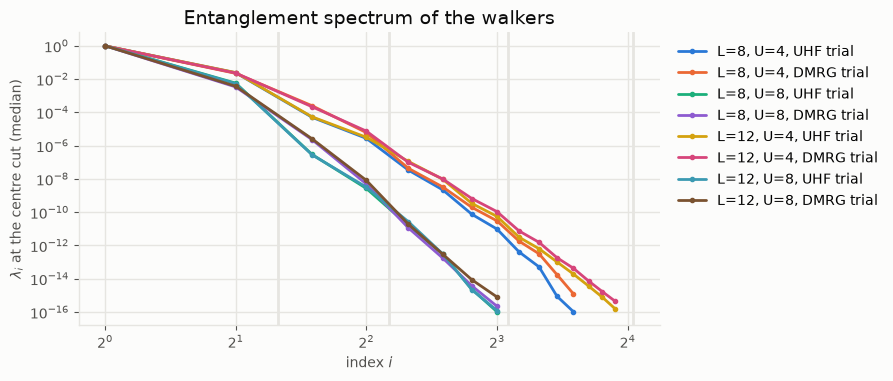

In [60]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, r in R.items():
    lam = r["centre_lam"][RS[name]][:, :, 0].reshape(-1, r["centre_lam"].shape[-1])
    i = np.arange(1, lam.shape[1] + 1)
    med = np.median(lam, 0)
    ok = med > 1e-16
    ax.plot(i[ok], med[ok], "o-", ms=3, color=COLOR[name], label=LABEL[name])
for c in CHIS:
    ax.axvline(c + 0.5, color=GRID, lw=2, zorder=0)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("index $i$"); ax.set_ylabel(r"$\lambda_i$ at the centre cut (median)")
ax.set_title("Entanglement spectrum of the walkers")
ax.legend(**LEGEND)
save(fig, "schmidt_spectrum_centre"); plt.show()

The plot above pools every sampling-phase snapshot. The spectra below are resolved in imaginary time: one line per analysed snapshot, each the median over its walkers of the $i$-th largest centre-cut Schmidt value, coloured by $\tau$. At $\tau=0$ every walker is the plan reference determinant, so the first line is its own spectrum. The legend marks the snapshots that fall in the equilibration phase.

saved entanglement_vs_gmps_data/schmidt_spectrum_tau_L12_U4_uhf.png


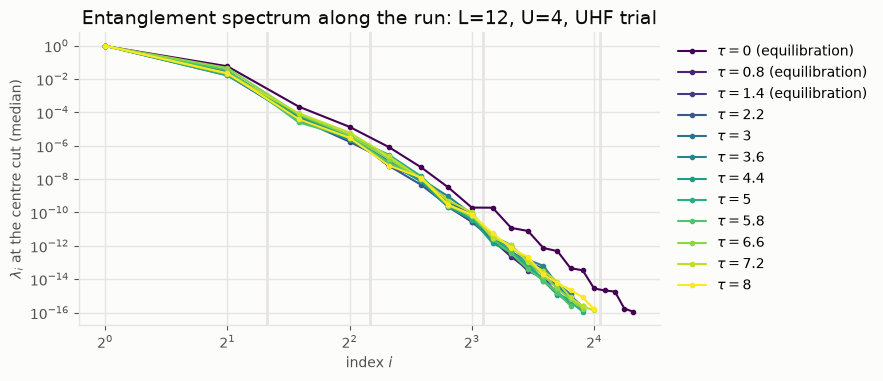

saved entanglement_vs_gmps_data/schmidt_spectrum_tau_L12_U4_dmrg.png


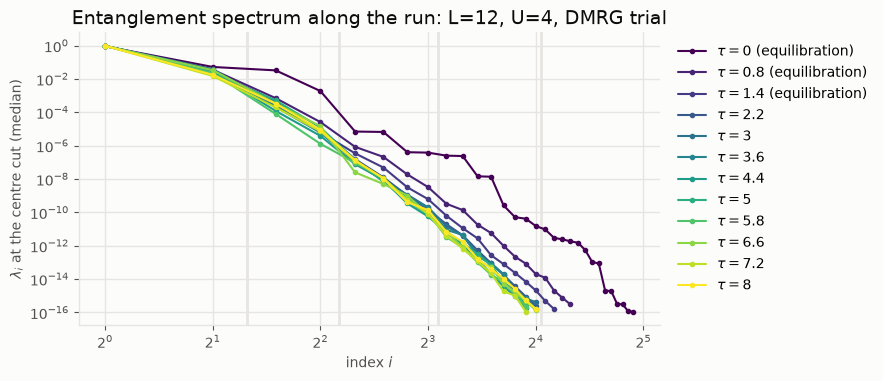

saved entanglement_vs_gmps_data/schmidt_spectrum_tau_L12_U8_uhf.png


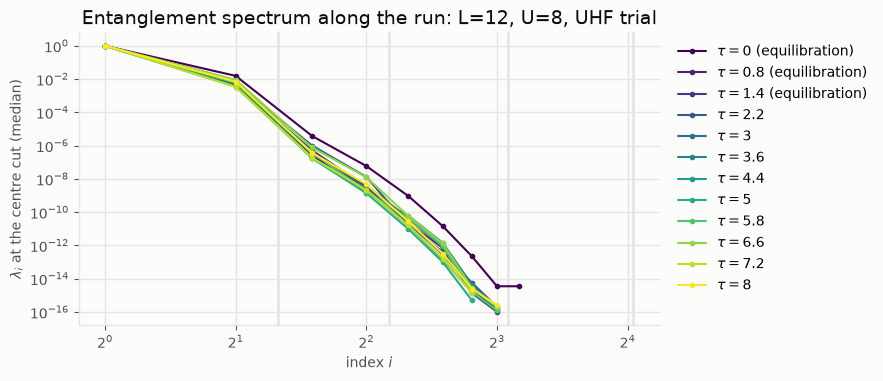

saved entanglement_vs_gmps_data/schmidt_spectrum_tau_L12_U8_dmrg.png


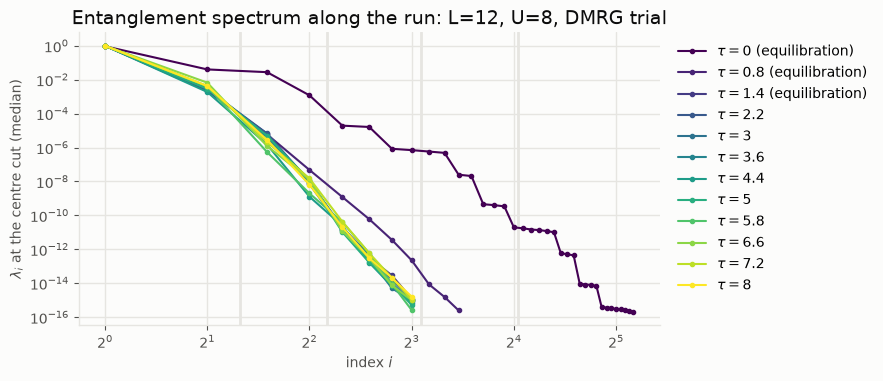

saved entanglement_vs_gmps_data/schmidt_lambda_vs_tau.png


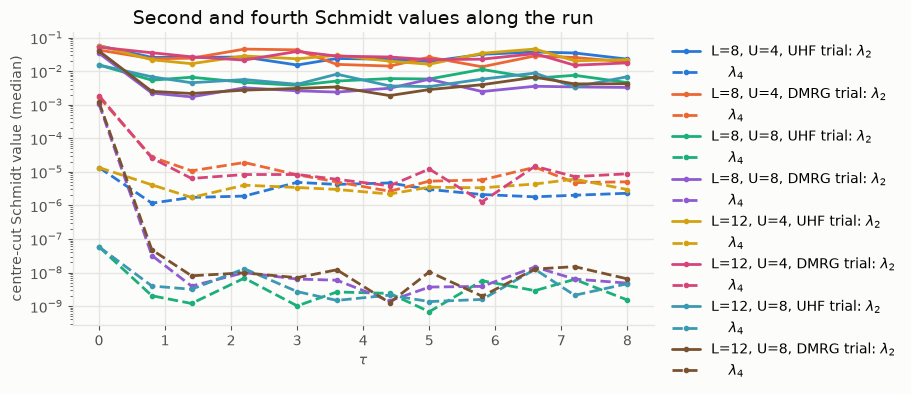

In [61]:
cmap = plt.get_cmap("viridis")
for name in [n for n in SETS if SETS[n]["L"] == 12]:
    r = R[name]
    taus, in_samp = TAU[name][r["snapshots"]], SAMP[name][r["snapshots"]]
    i = np.arange(1, r["centre_lam"].shape[-1] + 1)
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for j, t in enumerate(taus):
        med = np.median(r["centre_lam"][j, :, 0], 0)
        ok = med > 1e-16
        ax.plot(i[ok], med[ok], "o-", ms=3, lw=1.5, color=cmap(t / taus.max()),
                label=f"$\\tau={t:g}$" + ("" if in_samp[j] else " (equilibration)"))
    for c in CHIS:
        ax.axvline(c + 0.5, color=GRID, lw=2, zorder=0)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xlabel("index $i$"); ax.set_ylabel(r"$\lambda_i$ at the centre cut (median)")
    ax.set_title(f"Entanglement spectrum along the run: {LABEL[name]}")
    ax.legend(**LEGEND)
    save(fig, f"schmidt_spectrum_tau_{name}"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
t_end = max(TAU[n][-1] for n in SETS)
for name, r in R.items():
    taus = TAU[name][r["snapshots"]]
    keep = taus <= t_end
    for idx, ls, lab in ((1, "-", r"$\lambda_2$"), (3, "--", r"$\lambda_4$")):
        ax.plot(taus[keep], np.median(r["centre_lam"][keep][:, :, 0, idx], axis=1), ls, marker="o", ms=3, color=COLOR[name],
                label=f"{LABEL[name]}: {lab}" if idx == 1 else f"    {lab}")
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("centre-cut Schmidt value (median)")
ax.set_title("Second and fourth Schmidt values along the run")
ax.legend(**LEGEND)
save(fig, "schmidt_lambda_vs_tau"); plt.show()

## T1: entanglement along the run

The per-spin entropy at the most entangled cut, median and 10–90% band over walkers. The dotted line is $\ln 2$: one mode with $\nu=1/2$.

saved entanglement_vs_gmps_data/entropy_vs_tau.png


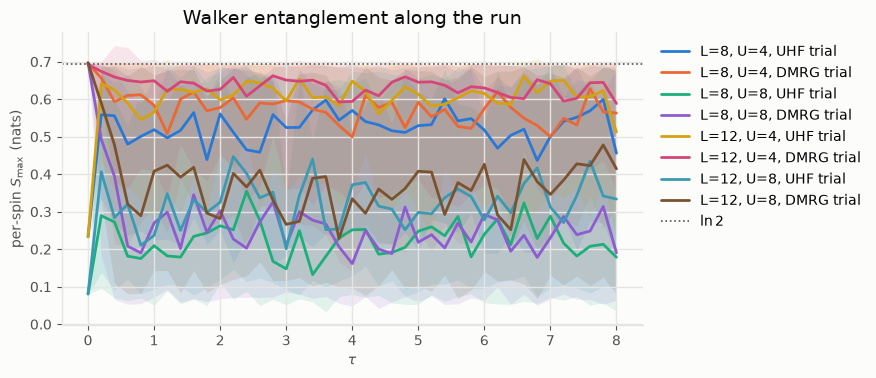

sampling phase, in sd_to_mps's convention (both spins, mean):   centre cut   max over cuts
  L8_U4_uhf                                             0.406        0.974
  L8_U4_dmrg                                            0.393        1.029
  L8_U8_uhf                                             0.166        0.575
  L8_U8_dmrg                                            0.133        0.595
  L12_U4_uhf                                            0.392        1.127
  L12_U4_dmrg                                           0.390        1.152
  L12_U8_uhf                                            0.177        0.717
  L12_U8_dmrg                                           0.161        0.750

sampling phase                per-spin S_max: median   99%     D_eff median   own-plan max B   fixed-plan max B
  L8_U4_uhf                            0.524   0.700      1.69            5                5
  L8_U4_dmrg                           0.573   0.726      1.77            5                5
  L8_U8_uh

In [62]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
t_end = max(TAU[n][-1] for n in SETS)
for name, r in R.items():
    smax = S_ALL[name].max(axis=2)
    keep = TAU[name] <= t_end
    ax.fill_between(TAU[name][keep], np.percentile(smax[keep], 10, 1), np.percentile(smax[keep], 90, 1),
                    color=COLOR[name], alpha=0.12, lw=0)
    ax.plot(TAU[name][keep], np.median(smax[keep], 1), color=COLOR[name], label=LABEL[name])
ax.axhline(np.log(2), color=INK2, ls=":", lw=1.2, label=r"$\ln 2$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"per-spin $S_{\max}$ (nats)")
ax.set_title("Walker entanglement along the run")
ax.legend(**LEGEND)
save(fig, "entropy_vs_tau"); plt.show()

# sd_to_mps.ipynb's convention (its "Molecular/Hubbard comparison" cell): S summed over both spins, mean over
# walkers (their weighted mean; weights are equal after reconfiguration), at the centre cut and at each walker's
# worst cut. S_down = S_up exactly here (particle-hole symmetry, T0), so the sum is 2 * S_up.
print("sampling phase, in sd_to_mps's convention (both spins, mean):   centre cut   max over cuts")
for name in SETS:
    S2 = 2 * S_ALL[name][SAMP[name]]
    print(f"  {name:14s}                                        {S2[:, :, SETS[name]['L'] // 2 - 1].mean():.3f}"
          f"        {S2.max(axis=2).mean():.3f}")
print()

print("sampling phase                per-spin S_max: median   99%     D_eff median   own-plan max B   fixed-plan max B")
for name, r in R.items():
    smax = r["S_dense"][RS[name]][:, :, 0].max(axis=2).ravel()
    print(f"  {name:14s}                       {np.median(smax):.3f}   {np.percentile(smax, 99):.3f}      {np.exp(np.median(smax)):.2f}"
          f"            {r['B'][RS[name]].max():d}                {PLAN[name][0].block_sizes.max():d}")

## T2: optimal vs achieved truncation

For each $\chi$, per walker spin channel:
- (a) the optimal worst cut, $\max_b\varepsilon_b(\chi)$, which no MPS with bond $\chi$ can beat;
- (b) $\sum_b\varepsilon_b(\chi)$;
- (c) optimal SVD compression of the exact state;
- (d) production;
- (e) production's circuit with **the walker's own kept counts**. This is `plan_bonds(Q, plan, χ)` run on the walker instead of on the reference. The value is the norm its truncation discards, plus the fixed plan's own loss $1-F_{\rm fixed}$, which to first order is that conversion's infidelity.

(c) and (d) are exact infidelities with respect to the dense walker. (e) separates the two ways production can lose:
- (e) close to (c) and far below (d) means the circuit is fine, and the loss comes from the **kept counts per charge sector frozen on the reference**;
- (e) close to (d) would mean the circuit itself is the loss.

Where $\chi$ reaches the fixed plan's full bond ($\chi=16$ for the UHF plan at $L=12$), production doesn't truncate at all. Its remaining error is the fixed-block loss, far above what a bond-16 MPS could achieve. The pass/fail condition is **(c), (d) ≥ (a)** to $10^{-12}$ for every walker. The ratio (d)/(a) shows how far production is from the best possible at the same bond. It includes frozen kept counts per charge sector, fixed blocks, and truncation inside the circuit.

In [63]:
print("sampling phase, per spin channel: medians (99th percentile in brackets)")
print(f"{'set':14s} {'chi':>4s}   {'(a) optimum':>19s}   {'(b) sum':>19s}   {'(c) SVD':>19s}   {'(d) production':>19s}   "
      f"{'(e) own counts':>19s}   {'d/a':>6s}   {'e/a':>6s}   {'dO walker':>9s}   violations")
for name, r in R.items():
    sm = RS[name]
    for k, c in enumerate(CHIS):
        col = lambda x: f"{np.median(x[sm][..., k]):8.1e} ({np.percentile(x[sm][..., k], 99):7.1e})"
        viol = int((r["c"][..., k] < r["a"][..., k] - 1e-12).sum() + (r["d"][..., k] < r["a"][..., k] - 1e-12).sum())
        ratio = lambda key: np.median(np.maximum(r[key][sm][..., k], 1e-16) / np.maximum(r["a"][sm][..., k], 1e-16))
        print(f"{name:14s} {c:4d}   {col(r['a'])}   {col(r['b'])}   {col(r['c'])}   {col(r['d'])}   {col(r['e'])}   "
              f"{ratio('d'):6.1f}   {ratio('e'):6.1f}   {np.median(r['dO'][sm][..., k]):9.1e}   {viol}")
    print()

sampling phase, per spin channel: medians (99th percentile in brackets)
set             chi           (a) optimum               (b) sum               (c) SVD        (d) production        (e) own counts      d/a      e/a   dO walker   violations
L8_U4_uhf         2    7.0e-04 (2.6e-02)    1.2e-03 (3.7e-02)    1.2e-03 (3.3e-02)    1.5e-03 (2.9e-01)    1.5e-03 (6.7e-02)      1.6      1.7     2.1e-03   0
L8_U4_uhf         4    2.6e-07 (9.7e-05)    3.7e-07 (1.1e-04)    3.6e-07 (1.1e-04)    1.3e-06 (1.4e-03)    4.4e-07 (1.1e-04)      2.8      1.4     3.3e-06   0
L8_U4_uhf         8    4.7e-13 (9.3e-10)    4.7e-13 (9.3e-10)    4.7e-13 (9.3e-10)    9.2e-13 (1.2e-08)    4.7e-13 (9.3e-10)      1.0      1.0     1.1e-08   0
L8_U4_uhf        16    5.6e-16 (1.3e-15)    1.0e-15 (2.8e-15)    0.0e+00 (4.4e-16)    0.0e+00 (4.4e-16)    0.0e+00 (4.4e-16)      0.2      0.2     1.1e-15   0

L8_U4_dmrg        2    1.4e-03 (4.6e-02)    2.2e-03 (6.0e-02)    2.1e-03 (5.9e-02)    5.1e-02 (9.9e-01)    2.7e-03 (1.

saved entanglement_vs_gmps_data/T2_truncation.png


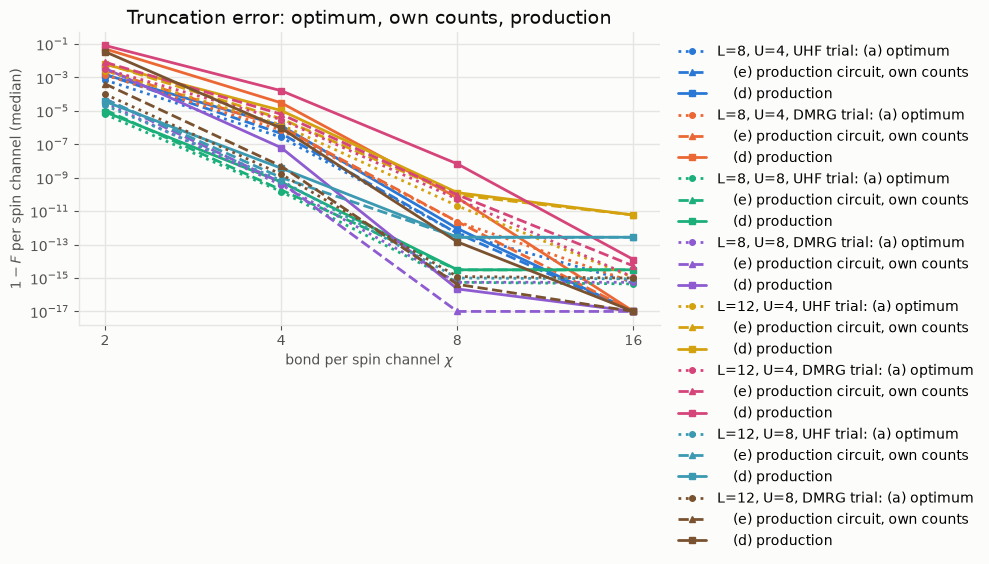

In [64]:
x = np.array(CHIS)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, r in R.items():
    a = np.clip(r["a"][RS[name]].reshape(-1, len(CHIS)), 1e-17, None)
    d = np.clip(r["d"][RS[name]].reshape(-1, len(CHIS)), 1e-17, None)
    e = np.clip(r["e"][RS[name]].reshape(-1, len(CHIS)), 1e-17, None)
    ax.plot(x, np.median(a, 0), ":", marker="o", ms=4, color=COLOR[name], label=f"{LABEL[name]}: (a) optimum")
    ax.plot(x, np.median(e, 0), "--", marker="^", ms=4, color=COLOR[name], label="    (e) production circuit, own counts")
    ax.plot(x, np.median(d, 0), "-", marker="s", ms=4, color=COLOR[name], label="    (d) production")
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHIS])
ax.set_xlabel(r"bond per spin channel $\chi$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
ax.set_title("Truncation error: optimum, own counts, production")
ax.legend(**LEGEND)
save(fig, "T2_truncation"); plt.show()

## T3: is $e^{S}$ the bond you need?

$\chi_{\rm needed}(\delta)$ is the smallest bond whose optimal worst-cut error is at most $\delta$, from the exact Schmidt values. It is shown for one spin (solid) and for the full walker (dashed), the d=4 MPS that production contracts, whose Schmidt values are $\lambda^\uparrow_i\lambda^\downarrow_j$. The dotted lines are the median $D_{\rm eff}=e^{S_{\max}}$ per spin, the scale sd_to_mps reports. For the full walker it is $e^{S_\uparrow+S_\downarrow}$, its square.

saved entanglement_vs_gmps_data/T3_chi_needed.png


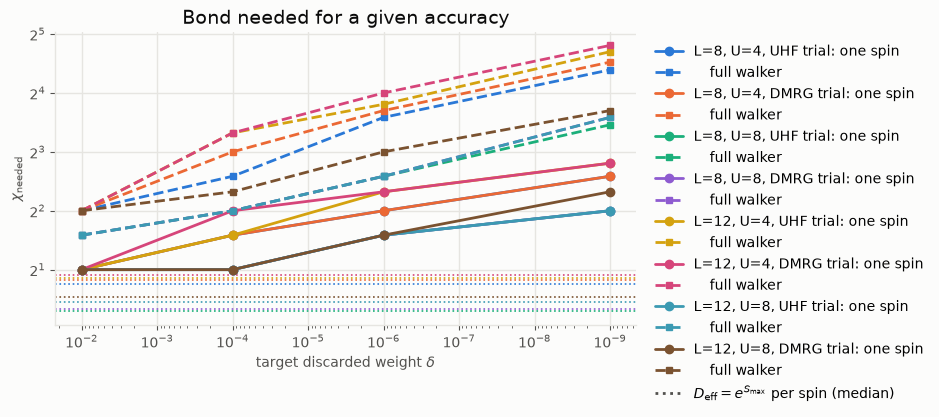

median chi_needed                 delta=1e-02  delta=1e-04  delta=1e-06  delta=1e-09   D_eff per spin
  L8_U4_uhf      one spin                  2            3            4            6   1.69
                 full walker               4            6           12           21
  L8_U4_dmrg     one spin                  2            3            4            6   1.77
                 full walker               4            8           13           23
  L8_U8_uhf      one spin                  2            2            3            4   1.22
                 full walker               3            4            6           11
  L8_U8_dmrg     one spin                  2            2            3            4   1.26
                 full walker               3            4            6           12
  L12_U4_uhf     one spin                  2            3            5            7   1.82
                 full walker               4           10           14           26
  L12_U4_dmrg    one sp

In [65]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, r in R.items():
    sm = RS[name]
    ax.plot(DELTAS, np.median(r["need"][sm].reshape(-1, len(DELTAS)), 0), "o-", color=COLOR[name], label=f"{LABEL[name]}: one spin")
    ax.plot(DELTAS, np.median(r["need_walker"][sm].reshape(-1, len(DELTAS)), 0), "s--", ms=4, color=COLOR[name], label="    full walker")
    ax.axhline(np.exp(np.median(r["S_dense"][sm][:, :, 0].max(axis=2))), color=COLOR[name], ls=":", lw=1.2)
ax.plot([], [], ":", color=INK2, label=r"$D_{\rm eff}=e^{S_{\max}}$ per spin (median)")
ax.set_xscale("log"); ax.set_yscale("log", base=2); ax.invert_xaxis()
ax.set_xlabel(r"target discarded weight $\delta$"); ax.set_ylabel(r"$\chi_{\rm needed}$")
ax.set_title("Bond needed for a given accuracy")
ax.legend(**LEGEND)
save(fig, "T3_chi_needed"); plt.show()

print(f"{'median chi_needed':32s}" + "".join(f"  delta={d:.0e}" for d in DELTAS) + "   D_eff per spin")
for name, r in R.items():
    sm = RS[name]
    one = np.median(r["need"][sm].reshape(-1, len(DELTAS)), 0)
    full = np.median(r["need_walker"][sm].reshape(-1, len(DELTAS)), 0)
    deff = np.exp(np.median(r["S_dense"][sm][:, :, 0].max(axis=2)))
    print(f"  {name:14s} one spin      " + "".join(f"  {v:11.0f}" for v in one) + f"   {deff:.2f}")
    print(f"  {'':14s} full walker   " + "".join(f"  {v:11.0f}" for v in full))

## T4: bonds, ranks and active modes

Three views of a walker's bond at each cut:
- the **Schmidt rank** above `RANK_TOL`, which is what the state needs;
- $2^{m_b}$, from the modes not pure to $\varepsilon$, which is what the Gaussian structure says;
- the **own-plan gMPS bond**, which is what the Fishman–White circuit produces untruncated.

The **fixed-plan bond** is also shown; it is the same for every walker. Everything is on a $\log_2$ scale, as the median over sampling-phase walkers, for the $L=12$ sets.

saved entanglement_vs_gmps_data/T4_bonds.png


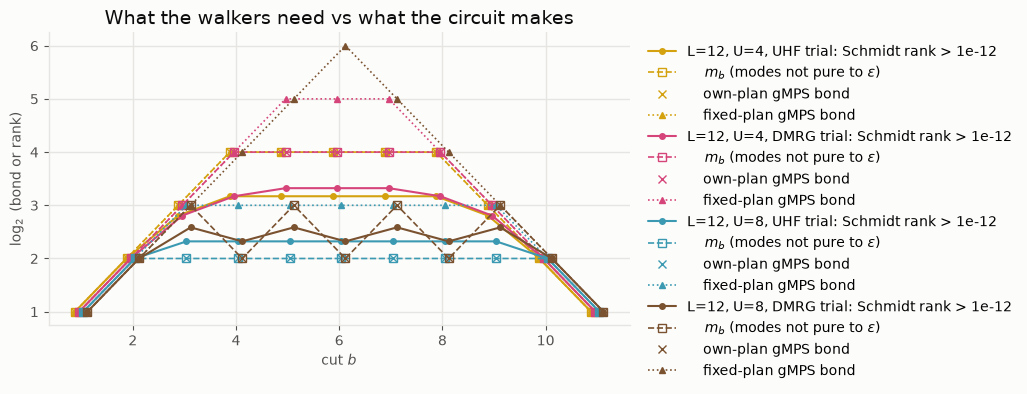

per walker and cut, all analysed snapshots:
  set              own-plan bond == 2^m_b    rank(> 1e-12) <= 2^(modes with w > 1e-12)
  L8_U4_uhf                99.98%                 100.00%
  L8_U4_dmrg              100.00%                 100.00%
  L8_U8_uhf                99.98%                 100.00%
  L8_U8_dmrg               99.98%                 100.00%
  L12_U4_uhf               99.80%                 100.00%
  L12_U4_dmrg              99.82%                 100.00%
  L12_U8_uhf               99.71%                 100.00%
  L12_U8_dmrg              99.66%                 100.00%

sampling phase: fraction of (walker, site) with B_k(phi) > B_k^ref, and the resulting fixed-plan loss
  L8_U4_uhf         0.00% of entries,    0.00% of walkers;  1-F_fixed median 0.0e+00  max 4.4e-16
  L8_U4_dmrg        0.00% of entries,    0.00% of walkers;  1-F_fixed median 0.0e+00  max 6.7e-16
  L8_U8_uhf         0.00% of entries,    0.00% of walkers;  1-F_fixed median 3.1e-15  max 6.2e-10
  L8_U8_

In [66]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
L_big = max(s["L"] for s in SETS.values())
shown = [n for n in SETS if SETS[n]["L"] == L_big]
for j, name in enumerate(shown):
    r, L = R[name], SETS[name]["L"]
    sm, cuts = RS[name], np.arange(1, L) + 0.08 * (j - (len(shown) - 1) / 2)     # small offsets keep equal values visible
    fixed = [t.shape[2] for t in channel_mps_np(REF[name][0], PLAN[name][0])[0][:-1]]
    ax.plot(cuts, np.median(np.log2(r["rank"][sm][:, :, 0].reshape(-1, L - 1)), 0), "o-", ms=4, lw=1.5, color=COLOR[name],
            label=f"{LABEL[name]}: Schmidt rank > {RANK_TOL:.0e}")
    ax.plot(cuts, np.median(r["m"][sm][:, :, 0].reshape(-1, L - 1), 0), "s--", ms=6, mfc="none", lw=1.2, color=COLOR[name],
            label=r"    $m_b$ (modes not pure to $\varepsilon$)")
    ax.plot(cuts, np.median(np.log2(r["bond_own"][sm][:, :, 0].reshape(-1, L - 1)), 0), "x", ms=6, color=COLOR[name],
            label="    own-plan gMPS bond")
    ax.plot(cuts, np.log2(fixed), "^:", ms=4, lw=1.2, color=COLOR[name], label="    fixed-plan gMPS bond")
ax.set_xlabel("cut $b$"); ax.set_ylabel(r"$\log_2$ (bond or rank)")
ax.set_title("What the walkers need vs what the circuit makes")
ax.legend(**LEGEND)
save(fig, "T4_bonds"); plt.show()

# a Schmidt value above tol is P0 * prod(w_k) over flipped modes, so every flipped mode has w_k > tol:
# the rank above tol is at most 2^(number of modes with w_k > tol), an identity to check exactly
def modes_above(Q, tol):
    out = []
    for nu in cut_spectra(Q):
        w = np.minimum(nu, 1 - nu) / np.maximum(nu, 1 - nu)
        out.append(int(np.sum(w > tol)))
    return np.array(out)


print("per walker and cut, all analysed snapshots:")
print(f"  set              own-plan bond == 2^m_b    rank(> {RANK_TOL:.0e}) <= 2^(modes with w > {RANK_TOL:.0e})")
for name, r in R.items():
    bond, m, rank = r["bond_own"], r["m"].astype(int), r["rank"]
    up = WALK[name][0][r["snapshots"]]
    m_tol = np.array([[modes_above(orthonormal(W), RANK_TOL) for W in snap] for snap in up])[:, :, None]
    print(f"  {name:14s}   {np.mean(bond == 2 ** m):14.2%}          {np.mean(rank <= 2 ** m_tol):14.2%}")

print("\nsampling phase: fraction of (walker, site) with B_k(phi) > B_k^ref, and the resulting fixed-plan loss")
for name, r in R.items():
    sm = RS[name]
    excess = r["B"][sm][:, :, 0] > PLAN[name][0].block_sizes[None, None]
    print(f"  {name:14s}  {excess.mean():7.2%} of entries,  {excess.any(axis=2).mean():7.2%} of walkers;"
          f"  1-F_fixed median {np.median(1 - r['F_fixed'][sm]):.1e}  max {(1 - r['F_fixed'][sm]).max():.1e}")

## Are the walkers site determinants?

A site determinant is a single occupation string $|n_1\dots n_L\rangle$: every orbital sits on one site, and it has no entanglement at all. The walkers' orbitals $Q$ are defined only up to a rotation among themselves, so their shape is shown in a gauge-free way:

- **Localized orbitals.** Pipek–Mezey, i.e. the rotation of $Q$'s columns that maximises $\sum_k\sum_i Q_{ik}^4$, the orbitals' weight on single sites. Each orbital's spread is its participation ratio $1/\sum_i Q_{ik}^4$: 1 for an orbital on one site, $L$ for one spread evenly.
- **Site occupations** $n_i=(QQ^{\mathsf T})_{ii}$, which are 0 or 1 exactly for a site determinant.
- **Best-string weight** $\max_n|\langle n|\phi\rangle|^2$, from the dense state: 1 for a site determinant.

All three are computed for spin ↑ on every snapshot, and for the plan reference determinant: the UHF determinant, or the DMRG trial's natural-orbital determinant.

In [67]:
def pipek_mezey(Q, sweeps=200, tol=1e-12):
    # real Jacobi sweeps maximising sum_k sum_i Q_ik^4 (Pipek-Mezey with site populations)
    Q = Q.copy()
    N = Q.shape[1]
    for _ in range(sweeps):
        change = 0.0
        for s in range(N):
            for t in range(s + 1, N):
                a, b = Q[:, s].copy(), Q[:, t].copy()
                A = np.sum((a * b) ** 2 - 0.25 * (a * a - b * b) ** 2)
                B = np.sum(a * b * (a * a - b * b))
                if A * A + B * B < 1e-24:
                    continue
                g = 0.25 * np.arctan2(B, -A)
                Q[:, s], Q[:, t] = np.cos(g) * a + np.sin(g) * b, -np.sin(g) * a + np.cos(g) * b
                change = max(change, abs(g))
        if change < tol:
            break
    return Q[:, np.argsort(np.argmax(Q ** 2, axis=0))]            # order orbitals by their main site


def localization(Q):
    loc = pipek_mezey(Q)
    n = np.einsum("ik,ik->i", Q, Q)
    return dict(best=float(np.max(dense_state(Q) ** 2)), spread=float(np.mean(1 / np.sum(loc ** 4, axis=0))),
                offsite=float(np.mean(np.minimum(n, 1 - n))))


def localization_all(name):
    up = WALK[name][0]
    rows = [[localization(orthonormal(W)) for W in snap] for snap in up]
    return {k: np.array([[r[k] for r in snap] for snap in rows]) for k in ("best", "spread", "offsite")}


LOC = {name: cached(DATA_DIR / f"{name}_localization.npz", lambda name=name: localization_all(name)) for name in SETS}
LOC_REF = {name: localization(REF[name][0]) for name in SETS}          # the plan reference determinant

print(f"{'sampling phase, spin up':24s}  {'best-string weight':>18s}  {'sites per orbital':>17s}  {'mean min(n, 1-n)':>16s}")
for name in SETS:
    sm, t = SAMP[name], LOC_REF[name]
    med = {k: np.median(LOC[name][k][sm]) for k in ("best", "spread", "offsite")}
    print(f"  {name:14s} plan ref  {t['best']:18.3f}  {t['spread']:17.2f}  {t['offsite']:16.3f}")
    print(f"  {'':14s} walkers   {med['best']:18.3f}  {med['spread']:17.2f}  {med['offsite']:16.3f}   (median)")

computed L8_U8_uhf_localization.npz in 1 s
computed L8_U8_dmrg_localization.npz in 1 s
computed L12_U8_uhf_localization.npz in 3 s
computed L12_U8_dmrg_localization.npz in 3 s
sampling phase, spin up   best-string weight  sites per orbital  mean min(n, 1-n)
  L8_U4_uhf      plan ref               0.641               1.24             0.103
                 walkers                0.629               1.25             0.102   (median)
  L8_U4_dmrg     plan ref               0.068               2.24             0.489
                 walkers                0.572               1.29             0.117   (median)
  L8_U8_uhf      plan ref               0.896               1.06             0.027
                 walkers                0.887               1.06             0.029   (median)
  L8_U8_dmrg     plan ref               0.071               2.18             0.484
                 walkers                0.889               1.06             0.029   (median)
  L12_U4_uhf     plan ref         

The localized orbitals of a typical sampling-phase walker: the one with the median best-string weight, in each $L=12$ set. Each coloured line is one orbital's density $Q_{ik}^2$. The black markers are the site occupations $n_i$, and the grey dashed lines are the plan reference determinant's localized orbitals.

saved entanglement_vs_gmps_data/orbitals_L12_U4_uhf.png


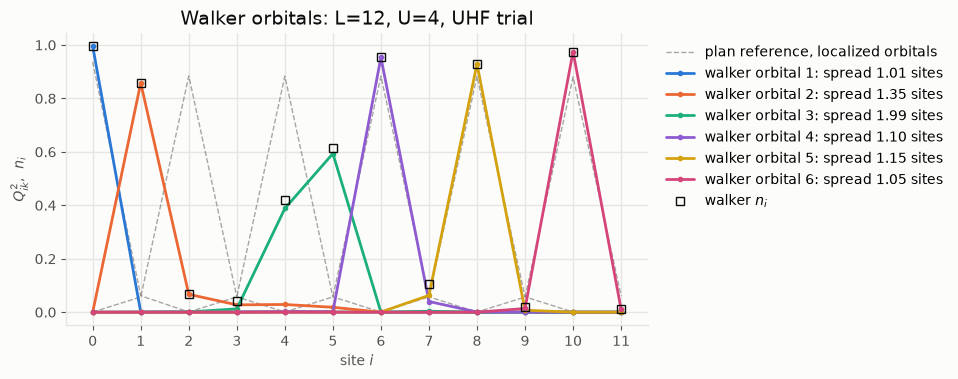

L12_U4_uhf: best-string weight 0.432, plan reference 0.499; per-spin S_max 0.667 nats
saved entanglement_vs_gmps_data/orbitals_L12_U4_dmrg.png


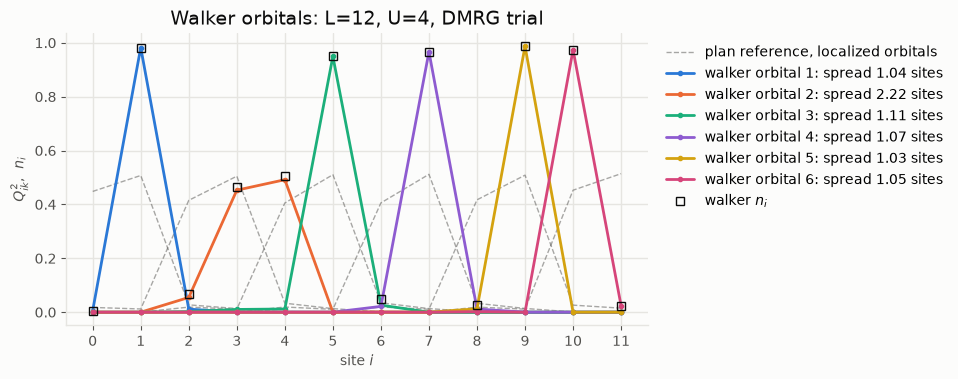

L12_U4_dmrg: best-string weight 0.425, plan reference 0.023; per-spin S_max 0.694 nats
saved entanglement_vs_gmps_data/orbitals_L12_U8_uhf.png


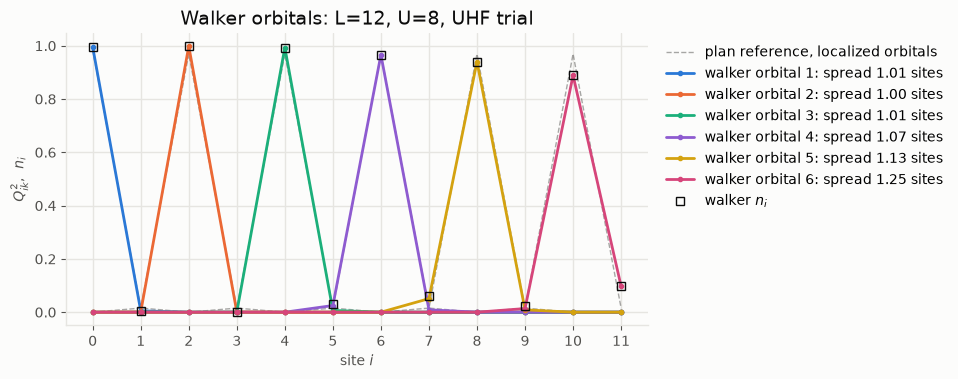

L12_U8_uhf: best-string weight 0.795, plan reference 0.841; per-spin S_max 0.320 nats
saved entanglement_vs_gmps_data/orbitals_L12_U8_dmrg.png


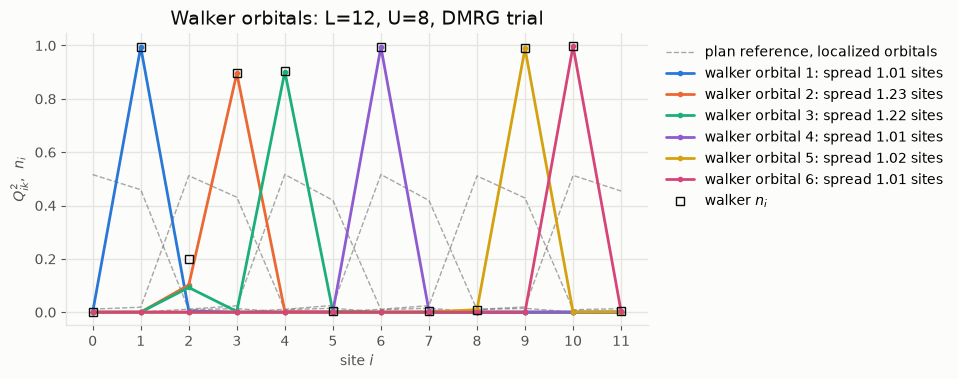

L12_U8_dmrg: best-string weight 0.782, plan reference 0.023; per-spin S_max 0.493 nats


In [68]:
for name in [n for n in SETS if SETS[n]["L"] == 12]:
    sm_idx = np.flatnonzero(SAMP[name])
    best = LOC[name]["best"][sm_idx]
    s_i, w_i = np.unravel_index(np.argsort(best, axis=None)[best.size // 2], best.shape)
    Q = orthonormal(WALK[name][0][sm_idx[s_i], w_i])
    loc, loc_t = pipek_mezey(Q), pipek_mezey(REF[name][0])
    sites = np.arange(SETS[name]["L"])
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for k in range(loc_t.shape[1]):
        ax.plot(sites, loc_t[:, k] ** 2, "--", color=INK2, lw=1, alpha=0.5, label="plan reference, localized orbitals" if k == 0 else None)
    for k in range(loc.shape[1]):
        ax.plot(sites, loc[:, k] ** 2, "-", marker="o", ms=3, color=PALETTE[k % len(PALETTE)],
                label=f"walker orbital {k + 1}: spread {1 / np.sum(loc[:, k] ** 4):.2f} sites")
    ax.plot(sites, np.einsum("ik,ik->i", Q, Q), "s", ms=6, mfc="none", color=INK, label=r"walker $n_i$")
    ax.set_xticks(sites)
    ax.set_xlabel("site $i$"); ax.set_ylabel(r"$Q_{ik}^2$,  $n_i$")
    ax.set_title(f"Walker orbitals: {LABEL[name]}")
    ax.legend(**LEGEND)
    save(fig, f"orbitals_{name}"); plt.show()
    print(f"{name}: best-string weight {LOC[name]['best'][sm_idx[s_i], w_i]:.3f}, "
          f"plan reference {LOC_REF[name]['best']:.3f}; per-spin S_max {S_ALL[name][sm_idx[s_i], w_i].max():.3f} nats")

How localization develops along the run: the median best-string weight, with its 10–90% band over walkers.

saved entanglement_vs_gmps_data/best_string_vs_tau.png


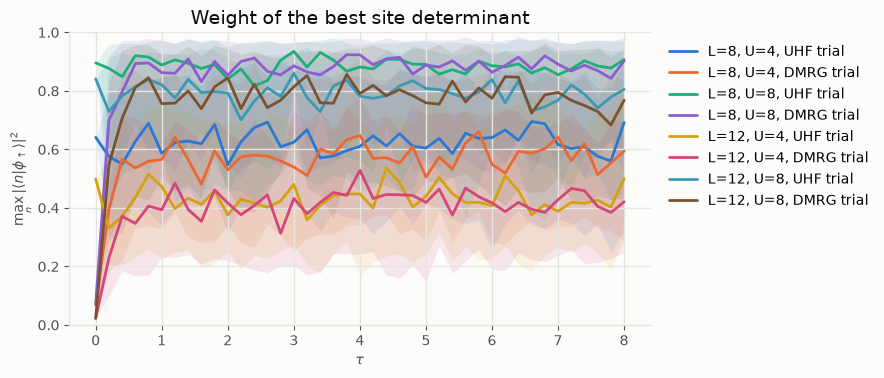

In [69]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
t_end = max(TAU[n][-1] for n in SETS)
for name in SETS:
    keep = TAU[name] <= t_end
    b = LOC[name]["best"][keep]
    ax.fill_between(TAU[name][keep], np.percentile(b, 10, 1), np.percentile(b, 90, 1), color=COLOR[name], alpha=0.12, lw=0)
    ax.plot(TAU[name][keep], np.median(b, 1), color=COLOR[name], label=LABEL[name])
ax.set_ylim(0, 1)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\max_n |\langle n|\phi_\uparrow\rangle|^2$")
ax.set_title("Weight of the best site determinant")
ax.legend(**LEGEND)
save(fig, "best_string_vs_tau"); plt.show()

## Why do frozen counts fail? Charge sectors

The orbitals also suggest why frozen counts fail, though I haven't tested this yet. A localized walker's Schmidt weight at a cut depends on how many electrons sit to its left, and where its shared electron sits. That differs from walker to walker and from the reference determinant the counts were frozen on. Checking the dominant charge sector per cut against the reference's allocation is quick at this size; I can add it next if you want.

**The test.** Both the walker and its gMPS conserve particle number, so the Schmidt decomposition at cut $b$ splits into charge sectors $q$ = the number of electrons left of the cut:
$$\lambda^{(b)}=\bigcup_q\lambda^{(b)}_{q},\qquad \lambda^{(b)}_{q}=\text{SVD of }\psi\text{ restricted to strings with }q\text{ electrons on sites }<b .$$
`plan_bonds` fixes how many kept states each sector gets, $k^{\rm ref}_q(b)$: its bond charge labels at cut $b$, `BondPlan.charges[b]`. No MPS with that allocation can keep more than the walker's $k^{\rm ref}_q$ largest values in each sector. So
$$\varepsilon^{\rm frozen}_b(\chi)=1-\sum_q\sum_{i\le k^{\rm ref}_q(b)}\lambda^{(b)}_{q,i},\qquad a^{\rm frozen}=\max_b\varepsilon^{\rm frozen}_b$$
is a hard lower bound for production, (d), which includes its frozen allocation. It lies at or above the unrestricted optimum (a).

- If (d) $\approx a^{\rm frozen}\gg$ (a), the allocation explains production's excess.
- The walker's **dominant sector** at a cut is the charge of its largest Schmidt value. If the frozen plan keeps no state there, the walker loses almost all its norm at that cut.

The sector values come from the dense state here. The bigger-size section below gets them from $\nu$ instead: each flipped mode moves the charge by $\pm1$, and the two routes are checked against each other.

In [70]:
@lru_cache(maxsize=None)
def _popcount(n_bits):
    return np.array([bin(i).count("1") for i in range(2 ** n_bits)])


def sector_schmidt(psi, L, N, b):
    # exact Schmidt values per left charge q at cut b: (values, charges), values descending
    M = psi.reshape(2 ** b, -1)
    pl, pr = _popcount(b), _popcount(L - b)
    vals, qs = [], []
    for q in range(max(0, N - (L - b)), min(b, N) + 1):
        blk = M[np.ix_(pl == q, pr == N - q)]
        if blk.size:
            s = np.linalg.svd(blk, compute_uv=False) ** 2
            vals.append(s); qs.append(np.full(len(s), q))
    vals, qs = np.concatenate(vals), np.concatenate(qs)
    order = np.argsort(-vals)
    return vals[order] / vals.sum(), qs[order]


def frozen_discarded(vals, qs, labels):
    # 1 - weight kept by an allocation with labels.count(q) states in sector q
    kept = 0.0
    for q in np.unique(labels):
        kept += vals[qs == q][: int(np.sum(labels == q))].sum()           # vals are descending
    return max(1.0 - kept, 0.0)


BONDS = {name: {c: plan_bonds(REF[name][0], PLAN[name][0], c, 0.0) for c in CHIS} for name in SETS}


def charge_sectors(name):
    up = WALK[name][0][R[name]["snapshots"]]
    n_sel, nw, L, N = up.shape
    out = dict(a_frozen=np.zeros((n_sel, nw, len(CHIS))), unkept=np.zeros((n_sel, nw, len(CHIS)), np.int16))
    for j in range(n_sel):
        for w in range(nw):
            psi = dense_state(orthonormal(up[j, w]))
            for b in range(1, L):
                vals, qs = sector_schmidt(psi, L, N, b)
                for k, c in enumerate(CHIS):
                    labels = BONDS[name][c].charges[b]
                    out["a_frozen"][j, w, k] = max(out["a_frozen"][j, w, k], frozen_discarded(vals, qs, labels))
                    out["unkept"][j, w, k] += int(np.sum(labels == qs[0]) == 0)
    return out


for name in SETS:
    R[name].update(cached(DATA_DIR / f"{name}_{EPS:.0e}_s{ANALYSE_SNAPSHOTS}_charge_sectors.npz", lambda name=name: charge_sectors(name)))

print("sampling phase, spin up: medians;  'unkept' = walkers whose dominant sector gets no kept state at some cut")
print(f"{'set':14s} {'chi':>4s}  {'(a) optimum':>12s}  {'a_frozen':>10s}  {'(d) production':>14s}  {'d/a':>7s}  {'d/a_frozen':>10s}  "
      f"{'unkept':>7s}  violations d < a_frozen")
for name, r in R.items():
    sm = RS[name]
    for k, c in enumerate(CHIS):
        a, af, d = r["a"][sm][:, :, 0, k], r["a_frozen"][sm][:, :, k], r["d"][sm][:, :, 0, k]
        ok = af > 1e-13
        ratio = np.median(d[ok] / af[ok]) if ok.any() else float("nan")
        viol = int(np.sum(r["d"][:, :, 0, k] < r["a_frozen"][:, :, k] - 1e-12))
        print(f"{name:14s} {c:4d}  {np.median(a):12.1e}  {np.median(af):10.1e}  {np.median(d):14.1e}  "
              f"{np.median(np.maximum(d, 1e-16) / np.maximum(a, 1e-16)):7.1f}  {ratio:10.2f}  "
              f"{np.mean(r['unkept'][sm][:, :, k] > 0):7.0%}  {viol}")
    print()

computed L8_U8_uhf_1e-10_s12_charge_sectors.npz in 0 s
computed L8_U8_dmrg_1e-10_s12_charge_sectors.npz in 1 s
computed L12_U8_uhf_1e-10_s12_charge_sectors.npz in 1 s
computed L12_U8_dmrg_1e-10_s12_charge_sectors.npz in 1 s
sampling phase, spin up: medians;  'unkept' = walkers whose dominant sector gets no kept state at some cut
set             chi   (a) optimum    a_frozen  (d) production      d/a  d/a_frozen   unkept  violations d < a_frozen
L8_U4_uhf         2       7.0e-04     8.2e-04         1.5e-03      1.6        1.36       0%  0
L8_U4_uhf         4       2.6e-07     1.1e-06         1.3e-06      2.8        1.10       0%  0
L8_U4_uhf         8       4.7e-13     9.2e-13         9.2e-13      1.0        1.00       0%  0
L8_U4_uhf        16       5.6e-16     1.1e-16         0.0e+00      0.2         nan       0%  0

L8_U4_dmrg        2       1.4e-03     1.7e-02         5.1e-02     29.0        1.51      10%  0
L8_U4_dmrg        4       7.0e-07     2.7e-05         3.0e-05     29.8      

One walker, one cut: the `CHARGE_SET` walker with the median production error at $\chi=4$, at the cut where the frozen allocation loses the most. The default is $L=12$, $U=4$ with the DMRG trial. The first plot shows how the walker's Schmidt weight splits over charge sectors, against the plan reference determinant's. The second shows how many kept states each sector gets at $\chi=4$: frozen on the reference, and the walker's own optimum (its 4 largest values).

saved entanglement_vs_gmps_data/sectors_weight.png


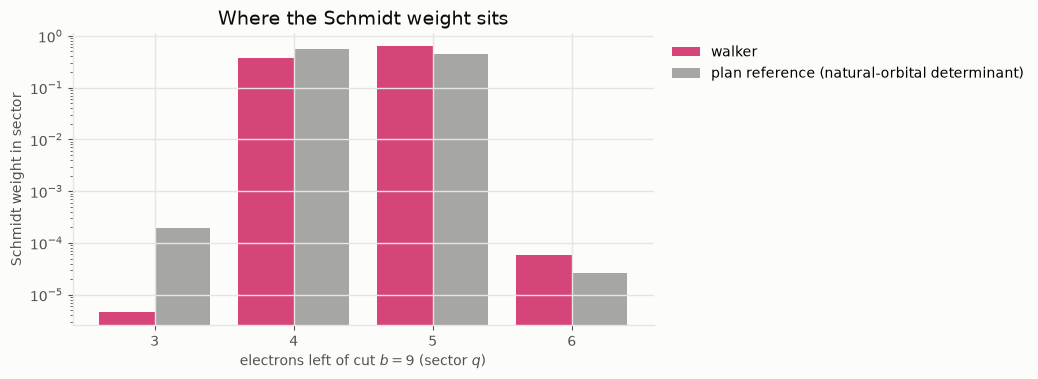

saved entanglement_vs_gmps_data/sectors_kept.png


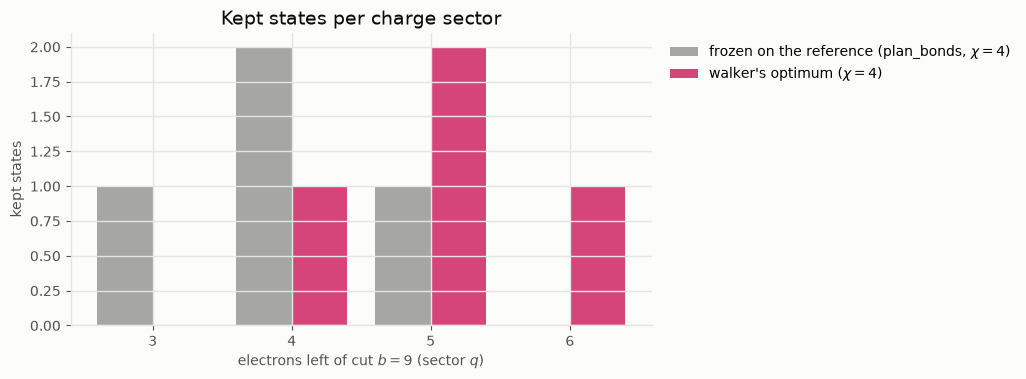

this walker at cut 9: frozen allocation discards 9.2e-05, the optimum 1.3e-05; production's total error 1.6e-04


In [71]:
CHARGE_SET = "L12_U4_dmrg"
name, chi, k = CHARGE_SET, 4, CHIS.index(4)
r, L, N = R[name], SETS[name]["L"], SETS[name]["L"] // 2
sm_idx = np.flatnonzero(RS[name])
d = r["d"][sm_idx][:, :, 0, k]
j, w = np.unravel_index(np.argsort(d, axis=None)[d.size // 2], d.shape)
Q = orthonormal(WALK[name][0][r["snapshots"][sm_idx[j]], w])
psi, psi_ref = dense_state(Q), dense_state(REF[name][0])
labels_all = BONDS[name][chi].charges
worst_b = max(range(1, L), key=lambda b: frozen_discarded(*sector_schmidt(psi, L, N, b), labels_all[b]))
vals, qs = sector_schmidt(psi, L, N, worst_b)
vals_r, qs_r = sector_schmidt(psi_ref, L, N, worst_b)
sectors = np.arange(max(0, N - (L - worst_b)), min(worst_b, N) + 1)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(sectors - 0.2, [vals[qs == q].sum() for q in sectors], width=0.4, color=PALETTE[5], label="walker")
ax.bar(sectors + 0.2, [vals_r[qs_r == q].sum() for q in sectors], width=0.4, color=INK2, alpha=0.5, label=f"plan reference ({REF_NAME[SETS[name]['trial']]})")
ax.set_yscale("log"); ax.set_xticks(sectors)
ax.set_xlabel(f"electrons left of cut $b={worst_b}$ (sector $q$)"); ax.set_ylabel("Schmidt weight in sector")
ax.set_title("Where the Schmidt weight sits")
ax.legend(**LEGEND)
save(fig, "sectors_weight"); plt.show()

own = qs[:chi]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(sectors - 0.2, [np.sum(labels_all[worst_b] == q) for q in sectors], width=0.4, color=INK2, alpha=0.5,
       label=f"frozen on the reference (plan_bonds, $\\chi={chi}$)")
ax.bar(sectors + 0.2, [np.sum(own == q) for q in sectors], width=0.4, color=PALETTE[5], label=f"walker's optimum ($\\chi={chi}$)")
ax.set_xticks(sectors)
ax.set_xlabel(f"electrons left of cut $b={worst_b}$ (sector $q$)"); ax.set_ylabel("kept states")
ax.set_title("Kept states per charge sector")
ax.legend(**LEGEND)
save(fig, "sectors_kept"); plt.show()
print(f"this walker at cut {worst_b}: frozen allocation discards {frozen_discarded(vals, qs, labels_all[worst_b]):.1e}, "
      f"the optimum {max(1 - vals[:chi].sum(), 0):.1e}; production's total error {d[j, w]:.1e}")

## A reference that looks like the walkers

Production freezes both the circuit and the kept counts on the DMRG trial's natural-orbital determinant. That determinant is delocalized; the walkers aren't. The alternative tested here is the **UHF reference**: the circuit and the counts come from the UHF determinant at the same $L$ and $U$, frozen once and applied to every DMRG-trial walker, as production would. It is localized like the walkers, but it has one fixed Néel pattern. The DMRG trial is paramagnetic, and its walkers come in both patterns.

Every variant is scored by its exact infidelity against the dense walker (spin ↑), on every analysed sampling snapshot:

| variant | circuit (block sizes, occupations) | kept counts per charge sector |
|---|---|---|
| production | natural orbitals | frozen on the natural orbitals |
| UHF | UHF determinant | frozen on the UHF determinant |
| (e) own counts | natural orbitals | each walker's own: the best this circuit allows |

A UHF circuit that doesn't fit a walker shows up already without truncation, as a large loss $1-F$ of the untruncated conversion. That loss is reported separately.

In [72]:
def better_references(name):
    s = SETS[name]
    L, N, U = s["L"], s["L"] // 2, s["U"]
    up, sel = WALK[name][0], R[name]["snapshots"]
    test = [j for j, snap in enumerate(sel) if SAMP[name][snap]]      # every analysed sampling snapshot
    C_uhf = uhf_scf(hopping_matrix(L, 1.0), U, N, N)[0]
    plan_uhf = make_orbital_plan(C_uhf, "adaptive", EPS)
    variants = {"uhf": (plan_uhf, lambda c: plan_bonds(C_uhf, plan_uhf, c, 0.0))}
    out = {v: np.zeros((len(test), up.shape[1], len(CHIS))) for v in variants}
    test_Q = [np.stack([orthonormal(W) for W in up[sel[j]]]) for j in test]
    test_psi = [[dense_state(Q) for Q in Qs] for Qs in test_Q]
    for v, (plan, make_bonds) in variants.items():
        for k, c in enumerate(CHIS):
            bond = make_bonds(c)
            convert = jax.jit(jax.vmap(lambda q, plan=plan, bond=bond: channel_mps(q, plan, bond)[::2]))
            for jj, Qs in enumerate(test_Q):
                tensors, _ = jax.tree_util.tree_map(np.asarray, convert(jnp.asarray(Qs)))
                for w in range(len(Qs)):
                    out[v][jj, w, k] = 1 - dense_fidelity(test_psi[jj][w], mps_to_dense([t[w] for t in tensors]))
    out["loss_uhf_plan"] = np.array([[1 - plan_fidelity(Q, plan_uhf) for Q in Qs] for Qs in test_Q])
    out["test"] = np.array(test)
    out["uhf_plan_max_B"] = np.array(plan_uhf.block_sizes.max())
    return out


DMRG_SETS = [n for n in SETS if SETS[n]["trial"] == "dmrg"]
BR = {name: cached(DATA_DIR / f"{name}_{EPS:.0e}_s{ANALYSE_SNAPSHOTS}_uhf_reference.npz", lambda name=name: better_references(name))
      for name in DMRG_SETS}

VARIANTS = [("prod", "production (NO)"), ("uhf", "UHF"), ("e", "(e) own counts")]


def variant_values(name, key):
    # (test snapshots, walkers, chi) infidelities of one variant, spin up
    r, test = R[name], BR[name]["test"]
    if key == "prod":
        return r["d"][test][:, :, 0]
    if key == "e":
        return r["e"][test][:, :, 0]
    return BR[name][key]


print("DMRG-trial walkers, sampling phase, spin up: median infidelity (99th percentile), and median ratio to the optimum")
for name in DMRG_SETS:
    a = R[name]["a"][BR[name]["test"]][:, :, 0]
    loss = BR[name]["loss_uhf_plan"]
    print(f"\n{LABEL[name]}: untruncated UHF-circuit loss 1-F median {np.median(loss):.1e}, 90% {np.percentile(loss, 90):.1e}, "
          f"max {loss.max():.1e};  UHF plan max B {int(BR[name]['uhf_plan_max_B'])}, NO plan max B {PLAN[name][0].block_sizes.max()}")
    print(f"  {'chi':>4s}  {'optimum':>18s}" + "".join(f"  {lab:>27s}" for _, lab in VARIANTS) + "   violations")
    for k, c in enumerate(CHIS):
        row = f"  {c:4d}  {np.median(a[..., k]):8.1e} ({np.percentile(a[..., k], 99):7.1e})"
        viol = 0
        for key, _ in VARIANTS:
            x = variant_values(name, key)[..., k]
            ok = a[..., k] > 1e-13
            ratio = np.median(x[ok] / a[..., k][ok]) if ok.any() else float("nan")
            row += f"  {np.median(x):8.1e} ({np.percentile(x, 99):7.1e}) x{ratio:7.1f}"
            if key != "e":
                viol += int(np.sum(x < a[..., k] - 1e-12))
        print(row + f"   {viol}")

computed L8_U8_dmrg_1e-10_s12_uhf_reference.npz in 3 s
computed L12_U8_dmrg_1e-10_s12_uhf_reference.npz in 5 s
DMRG-trial walkers, sampling phase, spin up: median infidelity (99th percentile), and median ratio to the optimum

L=8, U=4, DMRG trial: untruncated UHF-circuit loss 1-F median -4.4e-16, 90% 6.7e-16, max 2.2e-15;  UHF plan max B 5, NO plan max B 5
   chi             optimum              production (NO)                          UHF               (e) own counts   violations
     2   1.4e-03 (4.1e-02)   5.1e-02 (9.9e-01) x   29.0   4.3e-02 (9.7e-01) x   17.5   2.7e-03 (1.2e-01) x    1.7   0
     4   7.0e-07 (1.0e-04)   3.0e-05 (6.5e-02) x   29.8   2.7e-05 (1.2e-02) x   30.6   1.1e-06 (1.5e-04) x    1.3   0
     8   2.4e-12 (1.1e-08)   6.3e-11 (9.4e-07) x    3.4   6.3e-11 (9.4e-07) x    3.4   2.4e-12 (1.1e-08) x    1.0   0
    16   5.6e-16 (1.6e-15)   0.0e+00 (4.4e-16) x    nan   0.0e+00 (4.4e-16) x    nan   0.0e+00 (4.4e-16) x    nan   0

L=8, U=8, DMRG trial: untruncated UHF-cir

Infidelity ratios overstate the practical cost, because the optimal error falls so steeply with $\chi$. A more useful measure is the **equivalent bond**: the bond at which the optimum reaches a variant's median error. It is interpolated between the $\chi$ of the table, linearly in $\log$ error against $\log_2\chi$, on the medians. An equivalent bond of 6 at $\chi=8$ means the variant wastes a quarter of its bond.

In [73]:
def equivalent_bond(opt_median, err):
    # bond at which the (decreasing) median optimum reaches err, log-log interpolation between CHIS
    la, lx = np.log10(np.maximum(opt_median, 1e-300)), np.log2(np.array(CHIS, float))
    if err >= opt_median[0]:
        return float(CHIS[0])
    for i in range(len(CHIS) - 1):
        if opt_median[i] >= err >= opt_median[i + 1] and opt_median[i + 1] > 1e-14:   # above roundoff
            f = (la[i] - np.log10(err)) / (la[i] - la[i + 1])
            return float(2 ** (lx[i] + f * (lx[i + 1] - lx[i])))
    return float("nan")                                                 # beyond the resolved optimum


print("equivalent bond (the optimum's bond with the same median error), sampling phase, spin up")
print(f"  {'set':12s} {'chi':>4s}" + "".join(f"  {lab:>18s}" for _, lab in VARIANTS))
for name in DMRG_SETS:
    a_med = np.median(R[name]["a"][BR[name]["test"]][:, :, 0].reshape(-1, len(CHIS)), 0)
    for chi in (4, 8):
        k = CHIS.index(chi)
        row = f"  {name:12s} {chi:4d}"
        for key, _ in VARIANTS:
            row += f"  {equivalent_bond(a_med, np.median(variant_values(name, key)[..., k])):18.1f}"
        print(row)

equivalent bond (the optimum's bond with the same median error), sampling phase, spin up
  set           chi     production (NO)                 UHF      (e) own counts
  L8_U4_dmrg      4                 2.8                 2.9                 3.8
  L8_U4_dmrg      8                 6.7                 6.7                 nan
  L8_U8_dmrg      4                 2.9                 2.9                 3.9
  L8_U8_dmrg      8                 nan                 nan                 nan
  L12_U4_dmrg     4                 2.7                 2.6                 3.7
  L12_U4_dmrg     8                 5.9                 6.1                 7.7
  L12_U8_dmrg     4                 2.7                 2.8                 3.7
  L12_U8_dmrg     8                 nan                 nan                 nan


The same comparison as plots, one per $L=12$ DMRG set: the median infidelity of each variant against $\chi$, with the optimum as the dotted line.

saved entanglement_vs_gmps_data/better_refs_L12_U4_dmrg.png


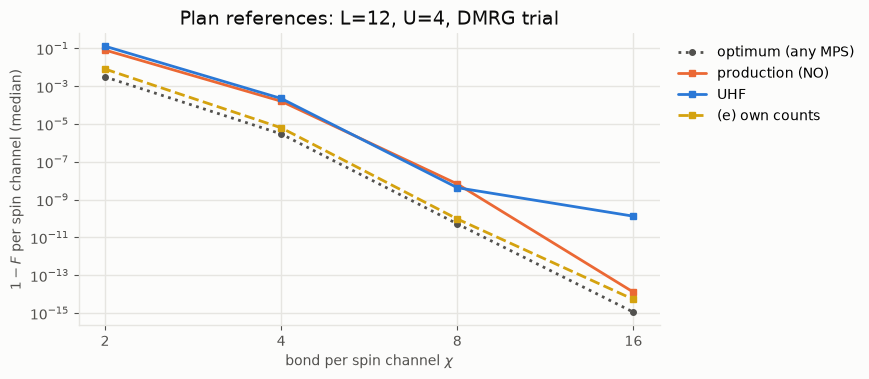

saved entanglement_vs_gmps_data/better_refs_L12_U8_dmrg.png


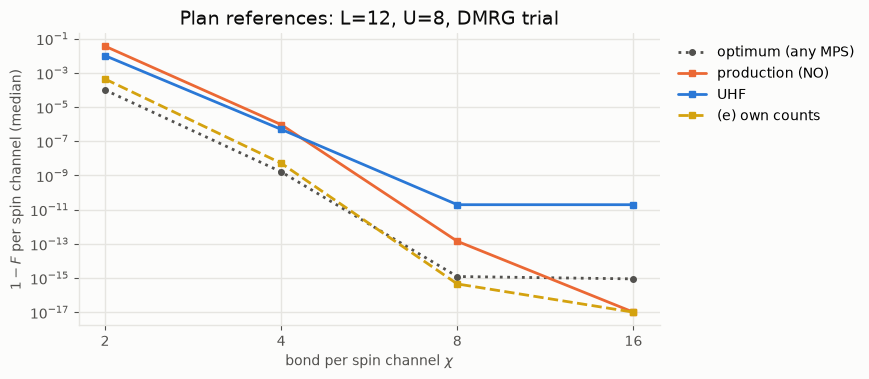

In [74]:
x = np.array(CHIS)
colors = {"prod": PALETTE[1], "uhf": PALETTE[0], "e": PALETTE[4]}
for name in [n for n in DMRG_SETS if SETS[n]["L"] == 12]:
    a = R[name]["a"][BR[name]["test"]][:, :, 0]
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.plot(x, np.median(np.clip(a, 1e-17, None).reshape(-1, len(CHIS)), 0), ":", marker="o", ms=4, color=INK2,
            label="optimum (any MPS)")
    for key, lab in VARIANTS:
        vals = np.clip(variant_values(name, key), 1e-17, None).reshape(-1, len(CHIS))
        ax.plot(x, np.median(vals, 0), "--" if key == "e" else "-", marker="s", ms=4, color=colors[key], label=lab)
    ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHIS])
    ax.set_xlabel(r"bond per spin channel $\chi$"); ax.set_ylabel(r"$1-F$ per spin channel (median)")
    ax.set_title(f"Plan references: {LABEL[name]}")
    ax.legend(**LEGEND)
    save(fig, f"better_refs_{name}"); plt.show()

## Summary

$L=8$ and $12$, $U=4$ and $6$, UHF and DMRG ($\chi_T=8$) trials; 50 walkers and 12 analysed snapshots per set, one seed each.

**The two notebooks agree, with the walkers' exact Schmidt values as the common ground truth.**

- The $\nu$ products give the dense Schmidt values to $5\times10^{-15}$ and the entropies to $7\times10^{-13}$. sd_to_mps's saved entropies are reproduced to $6\times10^{-14}$.
- The gMPS Schmidt values agree:
  - to $3\times10^{-10}$ with the walker's own plan (the purity tolerance $\varepsilon$);
  - with the fixed plan, to roundoff, or to its fixed-block loss ($\le5\times10^{-7}$) where a walker outgrows a block.
- fixed_block's $\det R[\mathrm{occ},:]^2$ equals the exact overlap to $4\times10^{-15}$.
- Nothing beats the optimum: 0 violations in every set.

**The runs.**

- **DMRG-trial CPMC** is within 0.0003–0.010 of the exact energy (e.g. $L=12$, $U=4$: $-6.5131$ against $-6.5232$).
- **UHF-trial CPMC** is 0.19–0.38 too high. The strongly broken-symmetry Néel trial is a poor constraint here.
- **Both trials' walkers look alike:** nearly site determinants (best-string weight 0.43–0.80, localized orbitals over 1.1–1.3 sites), with 0–2 electrons shared between neighbouring sites.

**Low entanglement means a small bond, but not $e^S$.** The per-spin $S_{\max}$ is 0.32–0.63 ($D_{\rm eff}=1.4$–$1.9$). The optimal bond per spin is 3–5 for a discarded weight of $10^{-6}$ and 5–7 for $10^{-9}$; for the full walker it is 10–16 and 15–28.

**Production depends on the plan reference.**

- **UHF trial.** The plan reference, the UHF determinant, is localized like the walkers. Production is 1.5–7× above the optimum at $\chi\le4$ (and at $\chi=8$ for $U=4$). Above that it reaches the fixed-block floor (median $\le5\times10^{-11}$).
- **DMRG trial, production's default.** The plan reference is the natural-orbital determinant, which is delocalized (best-string weight 0.02–0.07, orbitals over 2.2 sites), unlike the walkers.
  - At $L=12$ production is 18–240× above the optimum for $\chi=2$–$8$; at $L=8$ it is 29–94× for $\chi\le4$.
  - At $\chi=2$ the worst 1% of walkers lose essentially all their norm, and 8–11% of walkers have their dominant charge sector without a kept state at some cut.
- **The cause is the same for both: the per-sector kept counts frozen by `plan_bonds`.**
  - The same circuit with the walker's own counts, (e), is within 1.3–2.7× of the optimum wherever truncation dominates.
  - Production sits within 1.0–1.7× of the frozen-allocation bound.

**Fixed blocks** cost at most $5\times10^{-7}$ (worst walker) in every set. They matter only for the UHF plan, whose blocks ($B=4$–$5$) are below the rank bound; at $L=12$, $U=6$, 32% of walkers need a bigger block somewhere.

**Caveats.** One seed per set, 50 walkers, $\tau\le8$, $L\le12$.

**A reference that looks like the walkers doesn't fix it.** On the DMRG-trial walkers, freezing the circuit and counts on the UHF determinant gives about the same error as production. Where truncation dominates it is within about 3× either way.

- Both frozen references stay 18–250× above the optimum at $\chi=2$–$8$ ($L=12$).
- The UHF circuit also has an untruncated floor near $10^{-9}$ (worst $6\times10^{-5}$), because its one Néel pattern fits only some walkers. Where that floor dominates, it reaches 4800× the optimum.
- Only each walker's own counts reach the optimum.

The walkers differ from each other in how their Schmidt weight splits over charge sectors, which depends on where their shared electrons and domain walls sit. So any single allocation has to spread its kept states over sectors that most walkers don't use.

**In bond terms the cost is moderate.** Both frozen references at $\chi=4$ match the optimum at $\chi\approx2.6$–$2.9$, and at $\chi=8$ the optimum at $\chi\approx5.9$–$6.7$ (only 4.8 for the UHF circuit at $U=6$, where its floor dominates). The frozen allocation therefore wastes roughly a quarter to a third of the bond per spin channel. The walker's own counts reach 3.7–3.9 and 7.7.

**Next.** Only a per-walker allocation closes the gap. In production that needs every sector padded to the largest allocation any walker uses, since the shapes must be static. An earlier study found padding doesn't pay against a frozen allocation at the same padded bond ($L=16$); that is worth re-checking here with the exact reference. Otherwise, raising $\chi_w$ by about 40% buys back what the frozen allocation loses.